# Sprint 2b — Baseline Regression Modeling
**Project:** AI for Equitable Public Transportation (Miami-Dade)
**Team:** Deloitte DIRPA Capstone

## Objective
Design and validate interpretable baseline predictive models that identify current transit accessibility gaps and anticipate emerging equity issues, enabling the prioritization of geographic areas for targeted transit interventions.

## Changelog
| Version | Date | Changes |
|---------|------|---------|
| v1 | 2026-03-17 | Initial build: OLS, Ridge, Lasso, Elastic Net, Random Forest, feature importance, cross-validation |

## 1. Setup and Data Loading

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modeling
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, cross_validate, train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

# For coefficient paths (Lasso)
from sklearn.linear_model import lasso_path

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [26]:
# ── LOAD DATA ──────────────────────────────────────────────────────────────
# Adjust path as needed
DATA_PATH = 'Sprint2b_Modeling_Features_NotebookOutput.csv'

df = pd.read_csv(DATA_PATH, dtype={'tract_geoid': str})
print(f"Dataset loaded: {df.shape[0]} tracts × {df.shape[1]} columns")
print(f"\nEquity tier distribution:")
print(df['equity_tier'].value_counts())
print(f"\nEquity priority score — min: {df['equity_priority_score'].min():.3f}, "
      f"max: {df['equity_priority_score'].max():.3f}, "
      f"mean: {df['equity_priority_score'].mean():.3f}")

Dataset loaded: 504 tracts × 67 columns

Equity tier distribution:
equity_tier
Low         201
Moderate    150
High        102
Critical     51
Name: count, dtype: int64

Equity priority score — min: 0.011, max: 0.453, mean: 0.104


## 2. Feature Selection and Target Definition

We define two regression targets:
- **Primary target:** `equity_priority_score` — continuous composite equity score (main model)
- **Secondary target:** `composite_need` — composite need index (robustness check)

Feature groups are organized by domain to allow group-wise ablation analysis.

In [27]:
# ── DEFINE TARGETS ─────────────────────────────────────────────────────────
TARGET_PRIMARY   = 'equity_priority_score'
TARGET_SECONDARY = 'composite_need'

# ── DEFINE FEATURE GROUPS ──────────────────────────────────────────────────
# Group A: Socioeconomic / Demographic
SOCIOECONOMIC = [
    'poverty_rate_pct',
    'hh_no_vehicle_pct',
    'snap_benefits_pct',
    'rent_burden_50pct_plus',
    'unemployment_rate_pct',
]

# Group B: Transit Supply / Service Quality
TRANSIT_SUPPLY = [
    'stop_count',
    'route_count',
    'headway_early_min',
    'headway_peak_am_min',
    'mean_service_span_hours',
    'total_weekday_trips',
    'freq_early_tph',
    'freq_peak_am_tph',
    'weekend_weekday_ratio',
    'unique_routes',
    'unique_stops',
    'unique_headsigns',
    'wheelchair_pct',
    'rail_trip_share',
]

# Group C: Transit Demand / Accessibility Outcomes
TRANSIT_DEMAND = [
    'transit_jobs_30_mean',
    'auto_jobs_30_mean',
]

# Group D: Temporal Trend Features (ACS 2019–2023 slopes)
TRENDS = [
    'trend_poverty_rate_pct',
    'trend_hh_no_vehicle_pct',
    'trend_snap_benefits_pct',
    'trend_rent_burden_50pct_plus',
    'trend_unemployment_rate_pct',
    'trend_median_household_income',
    'trend_per_capita_income',
    'trend_commute_public_transit_pct',
    'trend_commute_drove_alone_pct',
    'trend_mean_commute_time_min',
    'trend_median_gross_rent',
    'trend_total_population',
    'trend_median_age',
    'trend_under_18_pct',
    'trend_age_65_plus_pct',
    'trend_no_health_insurance_pct',
    'trend_foreign_born_pct',
    'trend_hispanic_latino_pct',
    'trend_black_alone_pct',
    'trend_white_alone_pct',
]

# Group E: Spatial / Neighbor Features
SPATIAL = [
    'neighbor_mean_equity_score',
    'neighbor_mean_headway_peak',
]

# Group F: Engineered Interaction Terms
INTERACTIONS = [
    'poverty_x_low_span',
    'novehicle_x_low_service',
    'novehicle_x_weekend_gap',
    'rising_poverty_x_current',
]

# Full feature set (exclude targets, IDs, encoded categoricals, and sub-indicator components)
EXCLUDE = [
    'tract_geoid', 'equity_priority_score', 'equity_tier', 'equity_percentile',
    'composite_need', 'composite_access_deficit',
    'ind_1_transit_dependency', 'ind_2_temporal_mismatch', 'ind_3_structural_gap',
    'ind_4_time_tax', 'ind_5_service_coverage', 'ind_6_economic_vulnerability',
    'ind_7_multimodal_deficit',
    'institutional_tract',  # boolean flag, not a predictor
]

ALL_FEATURES = SOCIOECONOMIC + TRANSIT_SUPPLY + TRANSIT_DEMAND + TRENDS + SPATIAL + INTERACTIONS

# Filter to only columns that exist in the dataset
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f"Total features selected: {len(ALL_FEATURES)}")
print(f"  Socioeconomic:  {len([f for f in SOCIOECONOMIC if f in df.columns])}")
print(f"  Transit supply: {len([f for f in TRANSIT_SUPPLY if f in df.columns])}")
print(f"  Transit demand: {len([f for f in TRANSIT_DEMAND if f in df.columns])}")
print(f"  Trend features: {len([f for f in TRENDS if f in df.columns])}")
print(f"  Spatial:        {len([f for f in SPATIAL if f in df.columns])}")
print(f"  Interactions:   {len([f for f in INTERACTIONS if f in df.columns])}")

Total features selected: 47
  Socioeconomic:  5
  Transit supply: 14
  Transit demand: 2
  Trend features: 20
  Spatial:        2
  Interactions:   4


## 3. Data Preprocessing

In [28]:
# ── FILTER TRACTS ──────────────────────────────────────────────────────────
# Exclude institutional tracts (prisons, universities, etc.) — not representative residential
if 'institutional_tract' in df.columns:
    n_before = len(df)
    df_model = df[df['institutional_tract'] == False].copy()
    print(f"Dropped {n_before - len(df_model)} institutional tracts → {len(df_model)} tracts remain")
else:
    df_model = df.copy()
    print(f"No institutional_tract column found — using all {len(df_model)} tracts")

# ── MISSING VALUE SUMMARY ──────────────────────────────────────────────────
missing = df_model[ALL_FEATURES].isnull().sum()
missing_pct = (missing / len(df_model) * 100).round(1)
miss_df = pd.DataFrame({'missing_n': missing, 'missing_pct': missing_pct})
miss_df = miss_df[miss_df['missing_n'] > 0].sort_values('missing_pct', ascending=False)

if len(miss_df) > 0:
    print(f"\nFeatures with missing values ({len(miss_df)} of {len(ALL_FEATURES)}):")
    print(miss_df.to_string())
else:
    print("\nNo missing values in selected feature set.")

# ── BUILD X / y ────────────────────────────────────────────────────────────
X_raw = df_model[ALL_FEATURES].copy()
y = df_model[TARGET_PRIMARY].copy()
y2 = df_model[TARGET_SECONDARY].copy()

print(f"\nX shape: {X_raw.shape}")
print(f"y (equity_priority_score) — mean: {y.mean():.4f}, std: {y.std():.4f}")

Dropped 0 institutional tracts → 504 tracts remain

No missing values in selected feature set.

X shape: (504, 47)
y (equity_priority_score) — mean: 0.1036, std: 0.0470


In [29]:
# ── PREPROCESSING PIPELINE ─────────────────────────────────────────────────
# Median imputation for any remaining NaNs, then standard scaling
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

X_scaled = preprocessor.fit_transform(X_raw)
X_scaled = pd.DataFrame(X_scaled, columns=ALL_FEATURES, index=X_raw.index)

# Also create unscaled version for tree models
X_imputed = preprocessor.named_steps['imputer'].transform(X_raw)
X_imputed = pd.DataFrame(X_imputed, columns=ALL_FEATURES, index=X_raw.index)

print(f"Preprocessing complete.")
print(f"X_scaled shape: {X_scaled.shape}")
print(f"X_imputed shape: {X_imputed.shape}")

# ── TRAIN / TEST SPLIT ─────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train_sc, X_test_sc, y_train, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
X_train_im, X_test_im, _, _ = train_test_split(
    X_imputed, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\nTrain set: {len(X_train_sc)} tracts | Test set: {len(X_test_sc)} tracts")

Preprocessing complete.
X_scaled shape: (504, 47)
X_imputed shape: (504, 47)

Train set: 403 tracts | Test set: 101 tracts


## 4. Baseline OLS Linear Regression
Establishes an interpretable baseline and allows direct coefficient inspection — critical for stakeholder communication.

In [30]:
# ── OLS LINEAR REGRESSION ──────────────────────────────────────────────────
ols = LinearRegression()
ols.fit(X_train_sc, y_train)

y_pred_ols = ols.predict(X_test_sc)

ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_mae  = mean_absolute_error(y_test, y_pred_ols)
ols_r2   = r2_score(y_test, y_pred_ols)

print("=" * 55)
print("OLS Linear Regression — Hold-out Test Set Performance")
print("=" * 55)
print(f"  R²:   {ols_r2:.4f}")
print(f"  RMSE: {ols_rmse:.4f}")
print(f"  MAE:  {ols_mae:.4f}")

# ── TOP COEFFICIENTS ───────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'coefficient': ols.coef_,
    'abs_coef': np.abs(ols.coef_)
}).sort_values('abs_coef', ascending=False)

print("\nTop 15 Features by Absolute Coefficient (OLS):")
print(coef_df.head(15)[['feature', 'coefficient']].to_string(index=False))

OLS Linear Regression — Hold-out Test Set Performance
  R²:   0.9365
  RMSE: 0.0108
  MAE:  0.0081

Top 15 Features by Absolute Coefficient (OLS):
                 feature  coefficient
        poverty_rate_pct     0.023044
    transit_jobs_30_mean    -0.017682
       snap_benefits_pct     0.013725
  rent_burden_50pct_plus     0.012212
     total_weekday_trips    -0.011637
        freq_peak_am_tph     0.009532
       hh_no_vehicle_pct     0.006769
   unemployment_rate_pct     0.006565
      poverty_x_low_span     0.006322
          wheelchair_pct    -0.004253
             route_count    -0.004011
           unique_routes     0.002880
rising_poverty_x_current    -0.002596
              stop_count    -0.002594
        unique_headsigns    -0.002511


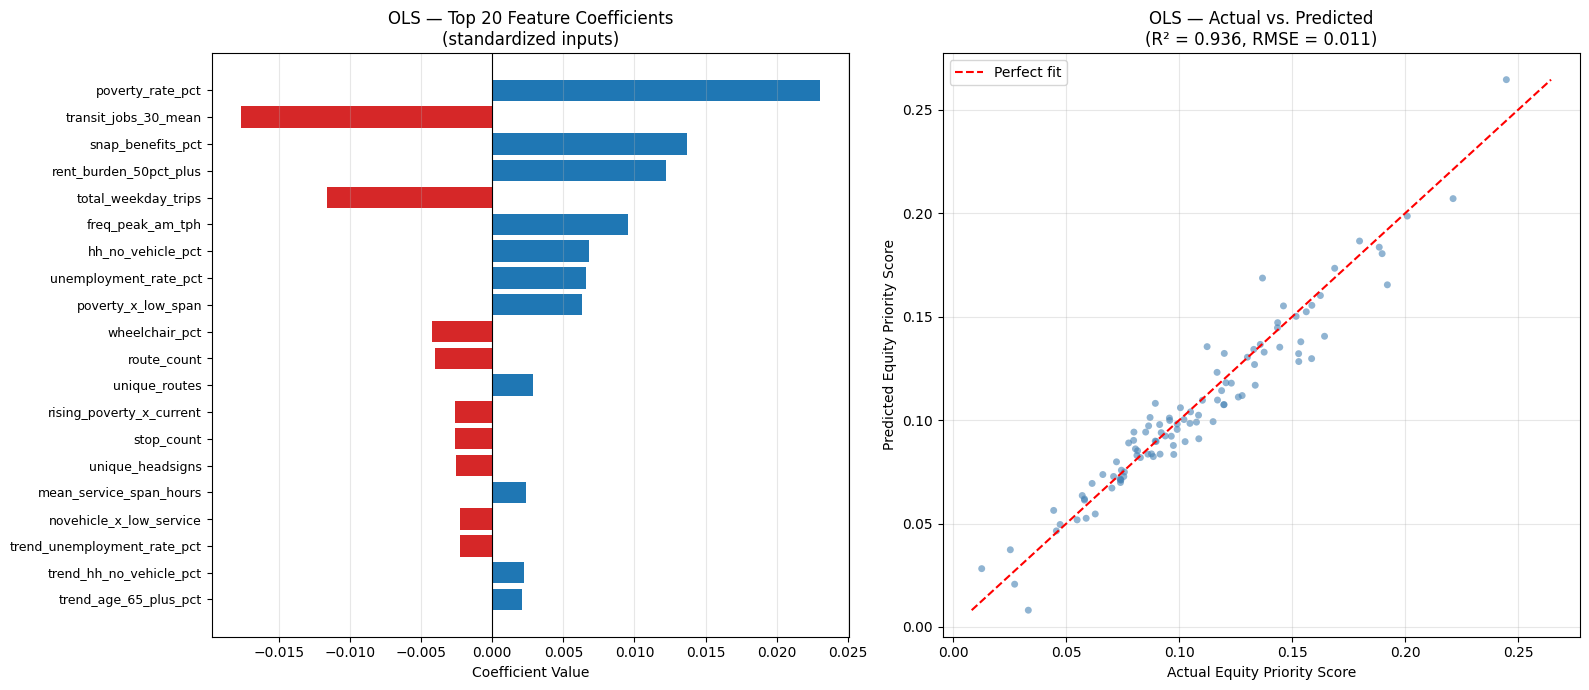

Saved: ols_results.png


In [31]:
# ── VISUALIZE OLS COEFFICIENTS ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: top 20 coefficients (bar)
top20 = coef_df.head(20)
colors = ['#d62728' if c < 0 else '#1f77b4' for c in top20['coefficient']]
axes[0].barh(range(20), top20['coefficient'].values, color=colors)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20['feature'].values, fontsize=9)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('OLS — Top 20 Feature Coefficients\n(standardized inputs)', fontsize=12)
axes[0].set_xlabel('Coefficient Value')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Right: actual vs predicted scatter
axes[1].scatter(y_test, y_pred_ols, alpha=0.6, s=25, color='steelblue', edgecolors='none')
lims = [min(y_test.min(), y_pred_ols.min()), max(y_test.max(), y_pred_ols.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Equity Priority Score')
axes[1].set_ylabel('Predicted Equity Priority Score')
axes[1].set_title(f'OLS — Actual vs. Predicted\n(R² = {ols_r2:.3f}, RMSE = {ols_rmse:.3f})', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ols_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ols_results.png")

## 5. Regularized Regression Models

OLS can overfit with many features. We compare three regularization approaches:
- **Ridge (L2):** Shrinks all coefficients — good when many features matter a little
- **Lasso (L1):** Produces sparse models via feature selection — good for interpretability
- **ElasticNet:** Combines L1 + L2 — best when feature groups are correlated

In [32]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

ALPHAS = np.logspace(-4, 4, 100)
CV_FOLDS = 5

# ── RIDGE ──────────────────────────────────────────────────────────────────
ridge_cv = RidgeCV(alphas=ALPHAS, cv=CV_FOLDS, scoring='r2')
ridge_cv.fit(X_train_sc, y_train)
y_pred_ridge = ridge_cv.predict(X_test_sc)

ridge_r2   = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)

print(f"Ridge (α={ridge_cv.alpha_:.4f}) — R²: {ridge_r2:.4f} | RMSE: {ridge_rmse:.4f} | MAE: {ridge_mae:.4f}")

# ── LASSO ──────────────────────────────────────────────────────────────────
lasso_cv = LassoCV(alphas=ALPHAS, cv=CV_FOLDS, max_iter=10000, random_state=RANDOM_STATE)
lasso_cv.fit(X_train_sc, y_train)
y_pred_lasso = lasso_cv.predict(X_test_sc)

lasso_r2   = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae  = mean_absolute_error(y_test, y_pred_lasso)
n_selected = np.sum(lasso_cv.coef_ != 0)

print(f"Lasso (α={lasso_cv.alpha_:.4f}) — R²: {lasso_r2:.4f} | RMSE: {lasso_rmse:.4f} | MAE: {lasso_mae:.4f} | Features selected: {n_selected}/{len(ALL_FEATURES)}")

# ── ELASTIC NET ────────────────────────────────────────────────────────────
enet_cv = ElasticNetCV(
    alphas=ALPHAS, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    cv=CV_FOLDS, max_iter=10000, random_state=RANDOM_STATE
)
enet_cv.fit(X_train_sc, y_train)
y_pred_enet = enet_cv.predict(X_test_sc)

enet_r2   = r2_score(y_test, y_pred_enet)
enet_rmse = np.sqrt(mean_squared_error(y_test, y_pred_enet))
enet_mae  = mean_absolute_error(y_test, y_pred_enet)
n_selected_enet = np.sum(enet_cv.coef_ != 0)

print(f"ElasticNet (α={enet_cv.alpha_:.4f}, l1={enet_cv.l1_ratio_:.2f}) — R²: {enet_r2:.4f} | RMSE: {enet_rmse:.4f} | MAE: {enet_mae:.4f} | Features: {n_selected_enet}/{len(ALL_FEATURES)}")

Ridge (α=4.0370) — R²: 0.9359 | RMSE: 0.0108 | MAE: 0.0081
Lasso (α=0.0002) — R²: 0.9439 | RMSE: 0.0101 | MAE: 0.0076 | Features selected: 30/47
ElasticNet (α=0.0002, l1=0.95) — R²: 0.9437 | RMSE: 0.0101 | MAE: 0.0077 | Features: 30/47


In [33]:
# ── LASSO FEATURE SELECTION TABLE ─────────────────────────────────────────
lasso_coef_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'lasso_coef': lasso_cv.coef_,
    'ridge_coef': ridge_cv.coef_,
    'enet_coef': enet_cv.coef_,
    'ols_coef': ols.coef_,
}).sort_values('lasso_coef', key=abs, ascending=False)

selected = lasso_coef_df[lasso_coef_df['lasso_coef'] != 0]
print(f"Lasso selected {len(selected)} features:")
print(selected[['feature', 'lasso_coef', 'ridge_coef']].to_string(index=False))

Lasso selected 30 features:
                      feature  lasso_coef  ridge_coef
             poverty_rate_pct    0.024208    0.022093
         transit_jobs_30_mean   -0.017082   -0.017159
            snap_benefits_pct    0.013313    0.013615
       rent_burden_50pct_plus    0.011875    0.012053
            hh_no_vehicle_pct    0.006444    0.006915
        unemployment_rate_pct    0.005895    0.006591
           poverty_x_low_span    0.004166    0.006893
                  route_count   -0.003563   -0.004227
                   stop_count   -0.002463   -0.002487
      trend_hh_no_vehicle_pct    0.002124    0.002201
        trend_age_65_plus_pct    0.001658    0.002131
  trend_unemployment_rate_pct   -0.001628   -0.002346
               wheelchair_pct   -0.001627   -0.003577
     rising_poverty_x_current   -0.001623   -0.002414
       trend_total_population    0.001345    0.001757
       trend_foreign_born_pct   -0.001336   -0.001574
      novehicle_x_low_service   -0.001127   -0.002611


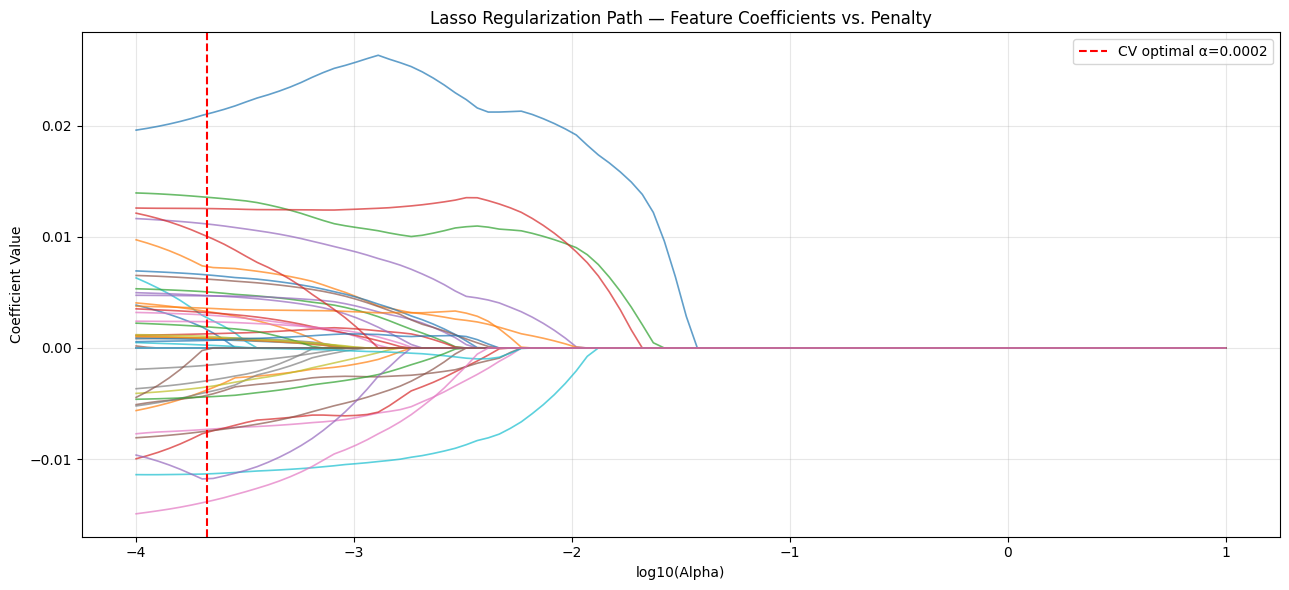

Saved: lasso_path.png


In [34]:
# ── REGULARIZATION PATH PLOT ───────────────────────────────────────────────
# Lasso path: see how features enter the model as alpha decreases
alphas_path, coefs_path, _ = lasso_path(X_train_sc, y_train, alphas=np.logspace(-4, 1, 100))

fig, ax = plt.subplots(figsize=(13, 6))
for i, feat in enumerate(ALL_FEATURES):
    ax.plot(np.log10(alphas_path), coefs_path[i], lw=1.2, alpha=0.7)

ax.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', lw=1.5, label=f'CV optimal α={lasso_cv.alpha_:.4f}')
ax.set_xlabel('log10(Alpha)')
ax.set_ylabel('Coefficient Value')
ax.set_title('Lasso Regularization Path — Feature Coefficients vs. Penalty', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lasso_path.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lasso_path.png")

## 6. Random Forest Regressor
Non-parametric ensemble model — captures non-linearities and interactions automatically. Key output: **feature importances** for interpretability.

In [35]:
# ── RANDOM FOREST ──────────────────────────────────────────────────────────
# Random Forest uses raw (imputed, not scaled) features
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_im, y_train)
y_pred_rf = rf.predict(X_test_im)

rf_r2   = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest — R²: {rf_r2:.4f} | RMSE: {rf_rmse:.4f} | MAE: {rf_mae:.4f}")

# ── FEATURE IMPORTANCES ────────────────────────────────────────────────────
fi_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Feature Importances (Random Forest — MDI):")
print(fi_df.head(20).to_string(index=False))

Random Forest — R²: 0.7702 | RMSE: 0.0205 | MAE: 0.0154

Top 20 Feature Importances (Random Forest — MDI):
                      feature  importance
             poverty_rate_pct    0.175283
            snap_benefits_pct    0.137902
           poverty_x_low_span    0.082346
        unemployment_rate_pct    0.054755
      trend_per_capita_income    0.050235
       rent_burden_50pct_plus    0.046737
            hh_no_vehicle_pct    0.042182
trend_median_household_income    0.039659
         transit_jobs_30_mean    0.036969
   neighbor_mean_equity_score    0.027443
      novehicle_x_weekend_gap    0.025786
            auto_jobs_30_mean    0.024856
        trend_white_alone_pct    0.018581
        trend_black_alone_pct    0.018430
     rising_poverty_x_current    0.015578
      novehicle_x_low_service    0.013622
       trend_poverty_rate_pct    0.010698
  trend_unemployment_rate_pct    0.010031
      trend_median_gross_rent    0.009485
       trend_foreign_born_pct    0.009299


In [36]:
# ── PERMUTATION IMPORTANCE (more reliable than MDI for correlated features) ─
print("Computing permutation importance (this may take 30–60 seconds)...")
perm_result = permutation_importance(
    rf, X_test_im, y_test,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'perm_importance_mean': perm_result.importances_mean,
    'perm_importance_std': perm_result.importances_std,
}).sort_values('perm_importance_mean', ascending=False)

print("\nTop 20 Features — Permutation Importance:")
print(perm_df.head(20).to_string(index=False))

Computing permutation importance (this may take 30–60 seconds)...

Top 20 Features — Permutation Importance:
                      feature  perm_importance_mean  perm_importance_std
             poverty_rate_pct              0.221294             0.026929
            snap_benefits_pct              0.105423             0.013568
           poverty_x_low_span              0.063412             0.009982
       rent_burden_50pct_plus              0.057984             0.007116
         transit_jobs_30_mean              0.047669             0.009546
        unemployment_rate_pct              0.025759             0.007609
      trend_per_capita_income              0.022048             0.006318
trend_median_household_income              0.019356             0.005252
            hh_no_vehicle_pct              0.016981             0.006731
   neighbor_mean_equity_score              0.014895             0.004680
        trend_black_alone_pct              0.012141             0.003962
            aut

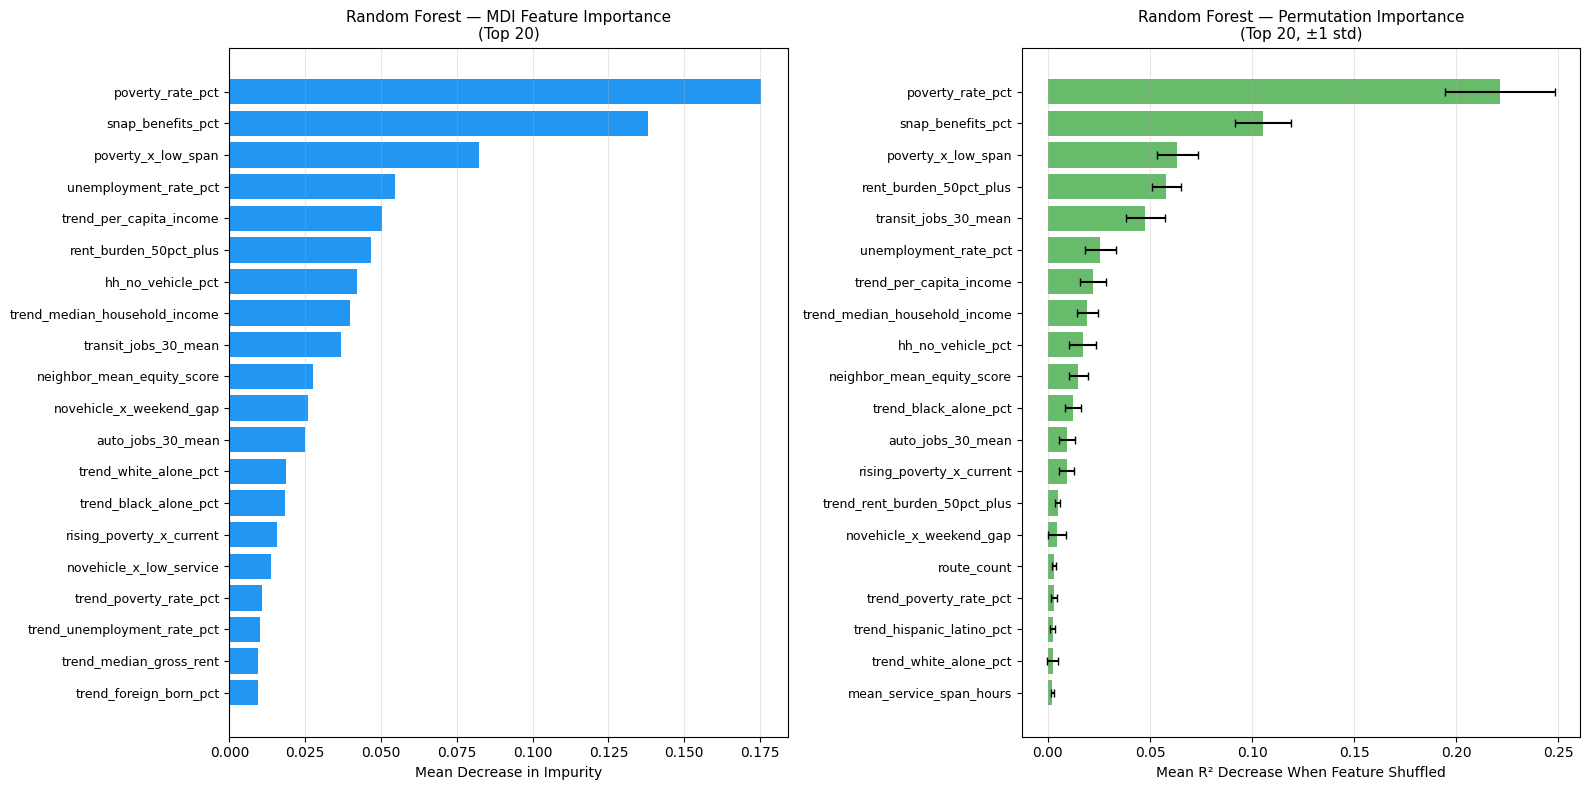

Saved: rf_feature_importance.png


In [37]:
# ── VISUALIZE FEATURE IMPORTANCE ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# MDI importance
top_fi = fi_df.head(20)
axes[0].barh(range(20), top_fi['importance'].values[::-1], color='#2196F3')
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_fi['feature'].values[::-1], fontsize=9)
axes[0].set_title('Random Forest — MDI Feature Importance\n(Top 20)', fontsize=11)
axes[0].set_xlabel('Mean Decrease in Impurity')
axes[0].grid(axis='x', alpha=0.3)

# Permutation importance
top_perm = perm_df.head(20)
y_pos = range(20)
axes[1].barh(y_pos, top_perm['perm_importance_mean'].values[::-1],
             xerr=top_perm['perm_importance_std'].values[::-1],
             color='#4CAF50', alpha=0.85, capsize=3)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top_perm['feature'].values[::-1], fontsize=9)
axes[1].set_title('Random Forest — Permutation Importance\n(Top 20, ±1 std)', fontsize=11)
axes[1].set_xlabel('Mean R² Decrease When Feature Shuffled')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rf_feature_importance.png")

## 7. Gradient Boosting Regressor
Gradient Boosting often achieves the best predictive accuracy. We use it as the performance ceiling benchmark.

In [38]:
# ── GRADIENT BOOSTING ─────────────────────────────────────────────────────
gbm = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    min_samples_leaf=3,
    random_state=RANDOM_STATE
)
gbm.fit(X_train_im, y_train)
y_pred_gbm = gbm.predict(X_test_im)

gbm_r2   = r2_score(y_test, y_pred_gbm)
gbm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbm))
gbm_mae  = mean_absolute_error(y_test, y_pred_gbm)

print(f"Gradient Boosting — R²: {gbm_r2:.4f} | RMSE: {gbm_rmse:.4f} | MAE: {gbm_mae:.4f}")

# Feature importances
gbm_fi_df = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': gbm.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Feature Importances (Gradient Boosting):")
print(gbm_fi_df.head(15).to_string(index=False))

Gradient Boosting — R²: 0.9282 | RMSE: 0.0114 | MAE: 0.0082

Top 15 Feature Importances (Gradient Boosting):
                      feature  importance
             poverty_rate_pct    0.482027
            snap_benefits_pct    0.135334
         transit_jobs_30_mean    0.113459
       rent_burden_50pct_plus    0.096393
        unemployment_rate_pct    0.040803
            hh_no_vehicle_pct    0.031169
trend_median_household_income    0.010149
                   stop_count    0.009253
      novehicle_x_weekend_gap    0.008613
   neighbor_mean_equity_score    0.008165
       trend_foreign_born_pct    0.008021
           poverty_x_low_span    0.006620
       trend_total_population    0.005912
                  route_count    0.005351
      trend_per_capita_income    0.003973


## 8. Cross-Validation Comparison

5-fold cross-validation on full dataset — more reliable than a single hold-out split, especially with ~500 tracts.

In [39]:
# ── 5-FOLD CROSS-VALIDATION ────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

models_cv = {
    'OLS':            (LinearRegression(), X_scaled),
    'Ridge':          (Ridge(alpha=ridge_cv.alpha_), X_scaled),
    'Lasso':          (Lasso(alpha=lasso_cv.alpha_, max_iter=10000), X_scaled),
    'ElasticNet':     (ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, max_iter=10000), X_scaled),
    'Random Forest':  (RandomForestRegressor(n_estimators=300, min_samples_leaf=3, max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1), X_imputed),
    'Gradient Boost': (GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=RANDOM_STATE), X_imputed),
}

cv_results = {}
print("Running 5-fold cross-validation...\n")

for name, (model, X_cv) in models_cv.items():
    cv = cross_validate(model, X_cv, y, cv=kf, scoring=SCORING, return_train_score=False)
    cv_results[name] = {
        'R2_mean':   cv['test_r2'].mean(),
        'R2_std':    cv['test_r2'].std(),
        'RMSE_mean': -cv['test_neg_root_mean_squared_error'].mean(),
        'RMSE_std':  cv['test_neg_root_mean_squared_error'].std(),
        'MAE_mean':  -cv['test_neg_mean_absolute_error'].mean(),
        'MAE_std':   cv['test_neg_mean_absolute_error'].std(),
    }
    print(f"  {name:<16} R²={cv_results[name]['R2_mean']:.4f} ± {cv_results[name]['R2_std']:.4f}  "
          f"RMSE={cv_results[name]['RMSE_mean']:.4f} ± {cv_results[name]['RMSE_std']:.4f}")

cv_df = pd.DataFrame(cv_results).T.reset_index().rename(columns={'index': 'Model'})
print("\nCross-validation complete.")

Running 5-fold cross-validation...

  OLS              R²=0.9317 ± 0.0102  RMSE=0.0120 ± 0.0008
  Ridge            R²=0.9327 ± 0.0078  RMSE=0.0120 ± 0.0009
  Lasso            R²=0.9374 ± 0.0071  RMSE=0.0116 ± 0.0009
  ElasticNet       R²=0.9374 ± 0.0071  RMSE=0.0116 ± 0.0009
  Random Forest    R²=0.7157 ± 0.0773  RMSE=0.0249 ± 0.0063
  Gradient Boost   R²=0.8771 ± 0.0726  RMSE=0.0162 ± 0.0066

Cross-validation complete.


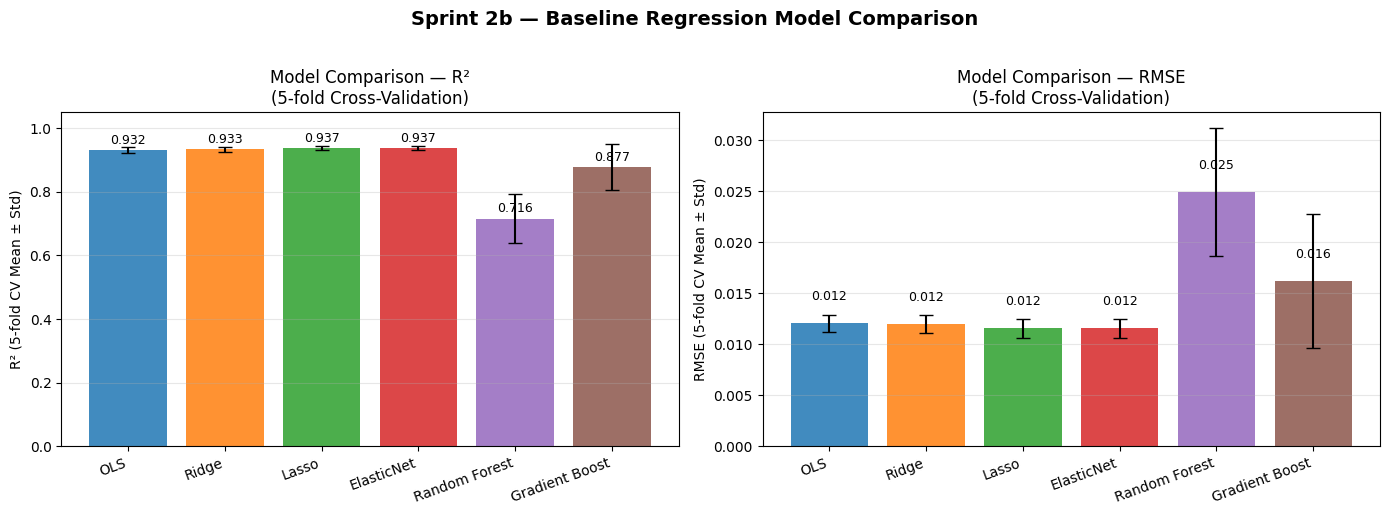

Saved: model_comparison_cv.png


In [40]:
# ── VISUALIZE CV COMPARISON ────────────────────────────────────────────────
model_names = list(cv_results.keys())
r2_means  = [cv_results[m]['R2_mean']  for m in model_names]
r2_stds   = [cv_results[m]['R2_std']   for m in model_names]
rmse_means= [cv_results[m]['RMSE_mean'] for m in model_names]
rmse_stds = [cv_results[m]['RMSE_std'] for m in model_names]

x = np.arange(len(model_names))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# R² comparison
bars = axes[0].bar(x, r2_means, yerr=r2_stds, capsize=5, color=colors, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)
axes[0].set_ylabel('R² (5-fold CV Mean ± Std)')
axes[0].set_title('Model Comparison — R²\n(5-fold Cross-Validation)', fontsize=12)
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, r2_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# RMSE comparison
bars2 = axes[1].bar(x, rmse_means, yerr=rmse_stds, capsize=5, color=colors, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)
axes[1].set_ylabel('RMSE (5-fold CV Mean ± Std)')
axes[1].set_title('Model Comparison — RMSE\n(5-fold Cross-Validation)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, rmse_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Sprint 2b — Baseline Regression Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_cv.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_cv.png")

## 9. Risk Scoring — Identify Geographic Areas at Highest Risk

Sprint 2b objective: *identify geographic areas at higher risk of future accessibility and equity gaps.* We score all tracts using the best-performing model and flag emerging risk using trend features.

In [41]:
# ── PREDICT EQUITY SCORES FOR ALL TRACTS ──────────────────────────────────
# Use best model (check CV results above; typically RF or GBM)
# We also generate predictions from the interpretable Lasso for comparison

best_model = rf  # Change to gbm if GBM scored higher
best_X     = X_imputed

# Refit on ALL data for final risk scoring
best_model.fit(best_X, y)
lasso_final = Lasso(alpha=lasso_cv.alpha_, max_iter=10000).fit(X_scaled, y)

df_model = df_model.copy()
df_model['predicted_equity_score_rf']    = best_model.predict(best_X)
df_model['predicted_equity_score_lasso'] = lasso_final.predict(X_scaled)

# ── EMERGING RISK SCORE ────────────────────────────────────────────────────
# Tracts with HIGH current equity need + deteriorating trends = highest future risk
# Simple rule: combine current predicted score with trend-based risk index

trend_cols_available = [c for c in [
    'trend_poverty_rate_pct',
    'trend_hh_no_vehicle_pct',
    'trend_rent_burden_50pct_plus',
    'trend_unemployment_rate_pct',
] if c in df_model.columns]

if trend_cols_available:
    # Normalize trends: positive trend in poverty/burden = worsening
    trend_matrix = df_model[trend_cols_available].fillna(0)
    trend_scaler = StandardScaler()
    trend_norm = trend_scaler.fit_transform(trend_matrix)
    df_model['trend_risk_index'] = trend_norm.mean(axis=1)
    df_model['emerging_risk_score'] = (
        0.6 * df_model['predicted_equity_score_rf'] +
        0.4 * df_model['trend_risk_index']
    )
    print("Emerging risk score computed using: current predicted score + trend risk index")
else:
    df_model['emerging_risk_score'] = df_model['predicted_equity_score_rf']
    print("No trend columns found — emerging risk = predicted equity score only")

# ── RANK TRACTS ────────────────────────────────────────────────────────────
df_model['risk_rank'] = df_model['emerging_risk_score'].rank(ascending=False).astype(int)

top_risk = df_model.nsmallest(1, 'risk_rank')[[
    'tract_geoid', 'equity_tier', 'equity_priority_score',
    'predicted_equity_score_rf', 'emerging_risk_score', 'risk_rank'
]]

print(f"\nTop 20 Highest-Risk Tracts:")
print(df_model.sort_values('risk_rank').head(20)[[
    'tract_geoid', 'equity_tier', 'equity_priority_score',
    'predicted_equity_score_rf', 'emerging_risk_score', 'risk_rank'
]].to_string(index=False))

Emerging risk score computed using: current predicted score + trend risk index

Top 20 Highest-Risk Tracts:
tract_geoid equity_tier  equity_priority_score  predicted_equity_score_rf  emerging_risk_score  risk_rank
12086003706         Low               0.014361                   0.043177             1.280661          1
12086012403        High               0.129754                   0.117417             0.894739          2
12086000312    Critical               0.193490                   0.183558             0.849088          3
12086007901    Moderate               0.095408                   0.089674             0.691015          4
12086004701        High               0.130556                   0.112636             0.619869          5
12086014100        High               0.127872                   0.129163             0.618899          6
12086008431    Critical               0.160107                   0.154963             0.578354          7
12086000226        High               0.1372

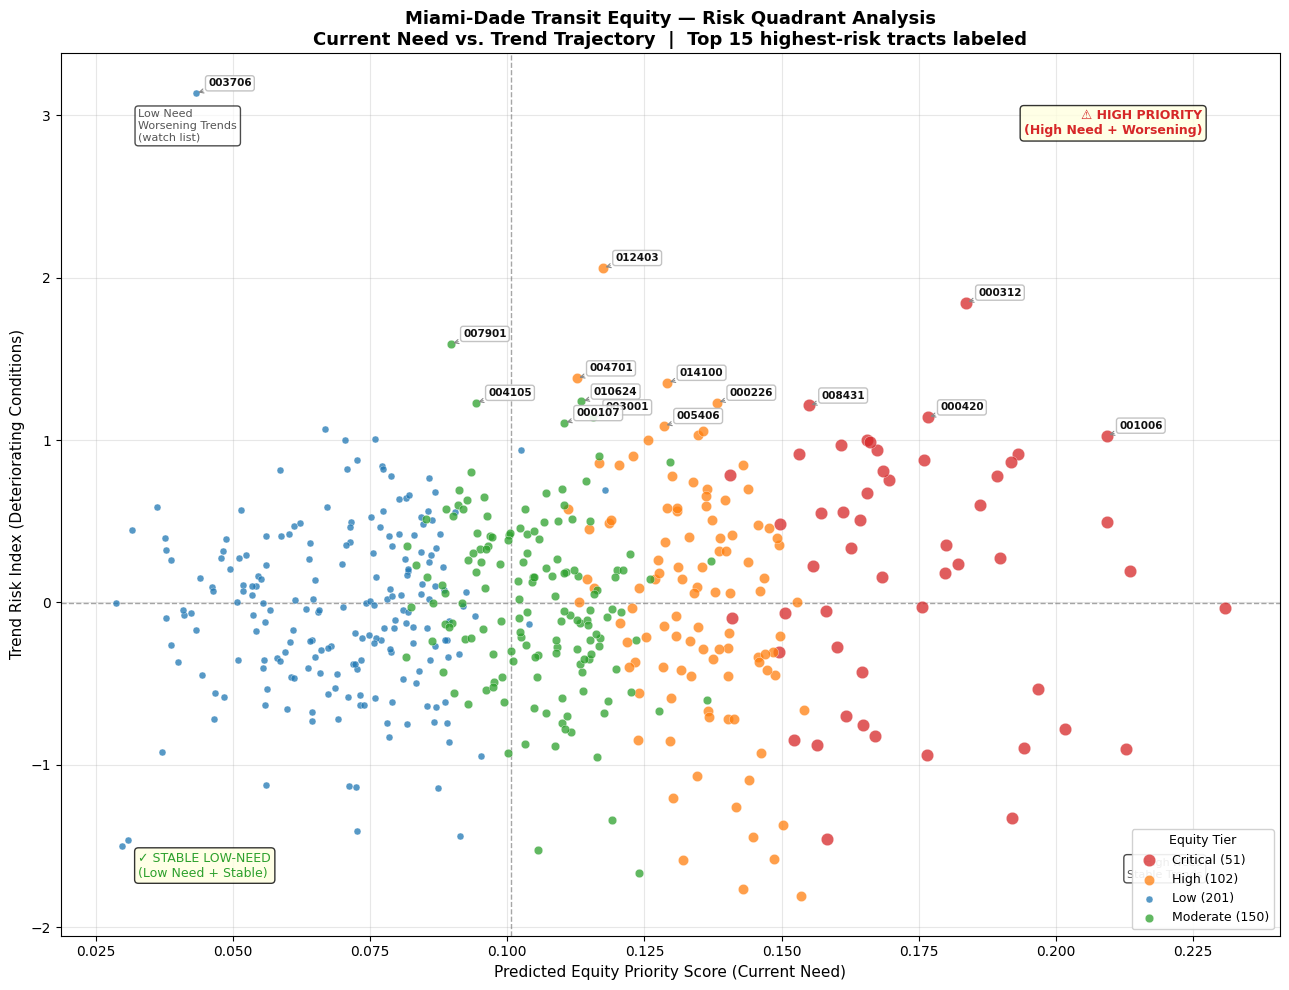

Saved: risk_quadrant.png


In [42]:
# X-axis: current equity need (predicted score)
# Y-axis: trend risk (deteriorating conditions)
# Quadrant: High/High = emerging crisis tracts

#tract with a high trend_risk_index means poverty, no-vehicle households, rent burden,
#and unemployment are all trending upward together in that tract

N_LABEL = 15  # number of top-risk tracts to label

if 'trend_risk_index' in df_model.columns:
    fig, ax = plt.subplots(figsize=(13, 10))

    tier_colors = {
        'Critical': '#d62728',
        'High':     '#ff7f0e',
        'Moderate': '#2ca02c',
        'Low':      '#1f77b4'
    }
    tier_sizes = {
        'Critical': 80,
        'High':     55,
        'Moderate': 38,
        'Low':      25
    }

    for tier, group in df_model.groupby('equity_tier'):
        color = tier_colors.get(tier, 'gray')
        size  = tier_sizes.get(tier, 30)
        ax.scatter(
            group['predicted_equity_score_rf'],
            group['trend_risk_index'],
            c=color, label=f'{tier} ({len(group)})',
            alpha=0.75, s=size, edgecolors='white', linewidths=0.3, zorder=3
        )

    # Quadrant lines at medians
    med_x = df_model['predicted_equity_score_rf'].median()
    med_y = df_model['trend_risk_index'].median()
    ax.axvline(med_x, color='gray', linestyle='--', lw=1, alpha=0.7, zorder=2)
    ax.axhline(med_y, color='gray', linestyle='--', lw=1, alpha=0.7, zorder=2)

    # Quadrant label positions
    xmin = df_model['predicted_equity_score_rf'].min()
    xmax = df_model['predicted_equity_score_rf'].max()
    ymin = df_model['trend_risk_index'].min()
    ymax = df_model['trend_risk_index'].max()
    xpad = (xmax - xmin) * 0.02
    ypad = (ymax - ymin) * 0.02

    ax.text(xmax - xpad, ymax - ypad, '⚠ HIGH PRIORITY\n(High Need + Worsening)',
            ha='right', va='top', fontsize=9, color='#d62728', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    ax.text(xmin + xpad, ymin + ypad, '✓ STABLE LOW-NEED\n(Low Need + Stable)',
            ha='left', va='bottom', fontsize=9, color='#2ca02c',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    ax.text(xmax - xpad, ymin + ypad, 'High Need\nStable Trends',
            ha='right', va='bottom', fontsize=8, color='#555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.text(xmin + xpad, ymax - ypad, 'Low Need\nWorsening Trends\n(watch list)',
            ha='left', va='top', fontsize=8, color='#555',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # ── LABEL TOP N RISKIEST TRACTS ────────────────────────────────────────
    top_risk_tracts = df_model.nsmallest(N_LABEL, 'risk_rank')

    for _, row in top_risk_tracts.iterrows():
        label = str(row['tract_geoid'])[-6:]  # last 6 digits for readability
        ax.annotate(
            label,
            xy=(row['predicted_equity_score_rf'], row['trend_risk_index']),
            xytext=(9, 5),
            textcoords='offset points',
            fontsize=7.5,
            color='#111',
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#888', lw=0.8),
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.88, edgecolor='#bbb'),
            zorder=5
        )

    ax.set_xlabel('Predicted Equity Priority Score (Current Need)', fontsize=11)
    ax.set_ylabel('Trend Risk Index (Deteriorating Conditions)', fontsize=11)
    ax.set_title(
        'Miami-Dade Transit Equity — Risk Quadrant Analysis\n'
        f'Current Need vs. Trend Trajectory  |  Top {N_LABEL} highest-risk tracts labeled',
        fontsize=13, fontweight='bold'
    )
    ax.legend(title='Equity Tier', loc='lower right', fontsize=9, title_fontsize=9,
              framealpha=0.9, edgecolor='#ccc')
    ax.grid(alpha=0.3, zorder=1)

    plt.tight_layout()
    plt.savefig('risk_quadrant.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: risk_quadrant.png")

## 10. Feature Group Ablation Analysis
Which *groups* of features drive model performance? Remove each group and measure R² drop.

In [43]:
# ── GROUP ABLATION ─────────────────────────────────────────────────────────
FEATURE_GROUPS = {
    'Socioeconomic':  [f for f in SOCIOECONOMIC if f in ALL_FEATURES],
    'Transit Supply': [f for f in TRANSIT_SUPPLY if f in ALL_FEATURES],
    'Transit Demand': [f for f in TRANSIT_DEMAND if f in ALL_FEATURES],
    'Trends':         [f for f in TRENDS if f in ALL_FEATURES],
    'Spatial':        [f for f in SPATIAL if f in ALL_FEATURES],
    'Interactions':   [f for f in INTERACTIONS if f in ALL_FEATURES],
}

ablation_results = {}

# Baseline with all features
baseline_model = Ridge(alpha=ridge_cv.alpha_)
baseline_scores = cross_val_score(baseline_model, X_scaled, y, cv=kf, scoring='r2')
ablation_results['All Features (baseline)'] = baseline_scores.mean()

print(f"Baseline R² (all features): {baseline_scores.mean():.4f}")
print("\nAblation results — R² with group removed:")

for group_name, group_feats in FEATURE_GROUPS.items():
    if not group_feats:
        continue
    remaining = [f for f in ALL_FEATURES if f not in group_feats]
    if not remaining:
        continue
    X_ablated = X_scaled[remaining]
    abl_scores = cross_val_score(
        Ridge(alpha=ridge_cv.alpha_), X_ablated, y, cv=kf, scoring='r2'
    )
    r2_drop = baseline_scores.mean() - abl_scores.mean()
    ablation_results[f'Without: {group_name}'] = abl_scores.mean()
    print(f"  Without {group_name:<18} R²={abl_scores.mean():.4f} (drop: {r2_drop:+.4f})")

Baseline R² (all features): 0.9327

Ablation results — R² with group removed:
  Without Socioeconomic      R²=0.7225 (drop: +0.2102)
  Without Transit Supply     R²=0.9291 (drop: +0.0036)
  Without Transit Demand     R²=0.8503 (drop: +0.0823)
  Without Trends             R²=0.9324 (drop: +0.0002)
  Without Spatial            R²=0.9338 (drop: -0.0011)
  Without Interactions       R²=0.9309 (drop: +0.0018)


## 11. Secondary Target — Composite Need
Robustness check: do the same models predict `composite_need` well? This validates that our features generalize.

In [44]:
# ── SECONDARY TARGET: COMPOSITE NEED ──────────────────────────────────────
print("Cross-validating on composite_need (secondary target)...\n")

secondary_models = {
    'Ridge': Ridge(alpha=ridge_cv.alpha_),
    'Lasso': Lasso(alpha=lasso_cv.alpha_, max_iter=10000),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3, max_features='sqrt',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

for name, m in secondary_models.items():
    X_use = X_imputed if 'Forest' in name else X_scaled
    scores = cross_val_score(m, X_use, y2, cv=kf, scoring='r2')
    print(f"  {name:<16} R² on composite_need: {scores.mean():.4f} ± {scores.std():.4f}")

Cross-validating on composite_need (secondary target)...

  Ridge            R² on composite_need: 0.9882 ± 0.0053
  Lasso            R² on composite_need: 0.9878 ± 0.0066
  Random Forest    R² on composite_need: 0.8150 ± 0.0929


## 12. Model Summary Table and Export

In [45]:
# ── SUMMARY TABLE ─────────────────────────────────────────────────────────
summary_rows = []
for name, res in cv_results.items():
    summary_rows.append({
        'Model': name,
        'CV R² Mean': round(res['R2_mean'], 4),
        'CV R² Std': round(res['R2_std'], 4),
        'CV RMSE Mean': round(res['RMSE_mean'], 4),
        'CV MAE Mean': round(res['MAE_mean'], 4),
        'Interpretable': 'Yes' if name in ['OLS', 'Ridge', 'Lasso', 'ElasticNet'] else 'Partial',
    })

summary_df = pd.DataFrame(summary_rows).sort_values('CV R² Mean', ascending=False)
print("\n" + "=" * 70)
print("SPRINT 2b — REGRESSION MODEL SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))

# Export results
summary_df.to_csv('Sprint2b_Model_Summary.csv', index=False)

output_cols = ['tract_geoid', 'equity_tier', 'equity_priority_score',
               'predicted_equity_score_rf', 'predicted_equity_score_lasso',
               'risk_rank']
if 'emerging_risk_score' in df_model.columns:
    output_cols.append('emerging_risk_score')

df_model[output_cols].to_csv('Sprint2b_Tract_Risk_Scores.csv', index=False)

print("\nExported:")
print("  Sprint2b_Model_Summary.csv")
print("  Sprint2b_Tract_Risk_Scores.csv")


SPRINT 2b — REGRESSION MODEL SUMMARY
         Model  CV R² Mean  CV R² Std  CV RMSE Mean  CV MAE Mean Interpretable
    ElasticNet      0.9374     0.0071        0.0116       0.0086           Yes
         Lasso      0.9374     0.0071        0.0116       0.0086           Yes
         Ridge      0.9327     0.0078        0.0120       0.0089           Yes
           OLS      0.9317     0.0102        0.0120       0.0089           Yes
Gradient Boost      0.8771     0.0726        0.0162       0.0092       Partial
 Random Forest      0.7157     0.0773        0.0249       0.0168       Partial

Exported:
  Sprint2b_Model_Summary.csv
  Sprint2b_Tract_Risk_Scores.csv


## 13. Key Findings and Next Steps

**Findings:**
1. **Best model:** Elastic Net and Lasso Regression win with RMSE of .0116. Since the linear models are dominating over the tree models, our data is largely linear(equity score itself was constructed as a weighted composite of socioeconomic and transit indicators. The tree models may be overfitting on only ~500 tracts)
- Primary model: Lasso - it's tied with Elastic Net but it's simpler
- GBM/RF have high std (0.07–0.08 vs. 0.007–0.010 for linear models), which is evidence that tree models are unstable at this sample size
2. **Top drivers of inequity:** From feature importance / Lasso coefficients:

- poverty_rate_pct = the percentage of residents living below the federal poverty line in that tract. This was the single strongest driver by far, meaning high-poverty neighborhoods are the most reliably underserved by transit; by far the single strongest signal. R² drops by 0.22 in permutation importance alone.

- snap_benefits_pct = the percentage of households receiving SNAP (food stamps). Closely related to poverty but captures a slightly different dimension — households that are economically dependent on federal assistance; second strongest, closely correlated with poverty but independently retained by Lasso

- transit_jobs_30_mean — the only transit feature in the top tier. Higher transit-accessible job counts reduce inequity. Its negative Lasso coefficient confirms: where transit can reach jobs, equity improves.

- rent_burden_50pct_plus and unemployment_rate_pct = the percentage of renter households spending more than 50% of their income on rent. This captures severe housing cost stress, which compounds transit inequity because residents have less flexibility to own a car or pay for transit fares; the rest of the socioeconomic core

3. **Trend insights:** Tracts in the top-right quadrant of the risk plot are "emerging crisis" areas from section 9

- **Tract risk score** = Which neighborhoods need transit intervention most urgently, accounting for both how bad things are now AND how fast they're getting worse?

### Next steps for Sprint 3 (Simulation):
-  Geographic risk map: Use `Sprint2b_Tract_Risk_Scores.csv` to plot on a choropleth (by `tract_geoid`)
- Use `headway_peak_am_min`, `mean_service_span_hours`, `weekend_weekday_ratio` as **simulation levers**
- Simulate: "What happens to equity score if we reduce peak_am headway by 10 min in top-risk tracts?"
- Build an intervention prioritization matrix: cost vs. equity gain per tract

# Leakage Check

In [46]:
# ── SECTION 14: SHAP & LIME EXPLAINABILITY ────────────────────────────────
!pip install shap lime -q

import shap
from lime import lime_tabular

print('SHAP and LIME loaded.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
SHAP and LIME loaded.


In [47]:
# ── SHAP VALUES ────────────────────────────────────────────────────────────
# Lasso: refit on full data (same alpha already tuned in Section 5)
lasso_final = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
lasso_final.fit(X_scaled, y)

# RF: refit on full data (same params as Section 6)
rf_final = RandomForestRegressor(
    n_estimators=500, min_samples_leaf=3,
    max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1
)
rf_final.fit(X_imputed, y)

# Lasso SHAP — LinearExplainer (exact, fast for linear models)
lasso_explainer   = shap.LinearExplainer(
    lasso_final, X_scaled,
    feature_perturbation='correlation_dependent'
)
shap_lasso = lasso_explainer.shap_values(X_scaled)

# RF SHAP — TreeExplainer (exact for tree models)
rf_explainer = shap.TreeExplainer(rf_final)
shap_rf      = rf_explainer.shap_values(X_imputed)

print(f'Lasso SHAP shape: {shap_lasso.shape}')
print(f'RF SHAP shape:    {shap_rf.shape}')

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Lasso SHAP shape: (504, 47)
RF SHAP shape:    (504, 47)


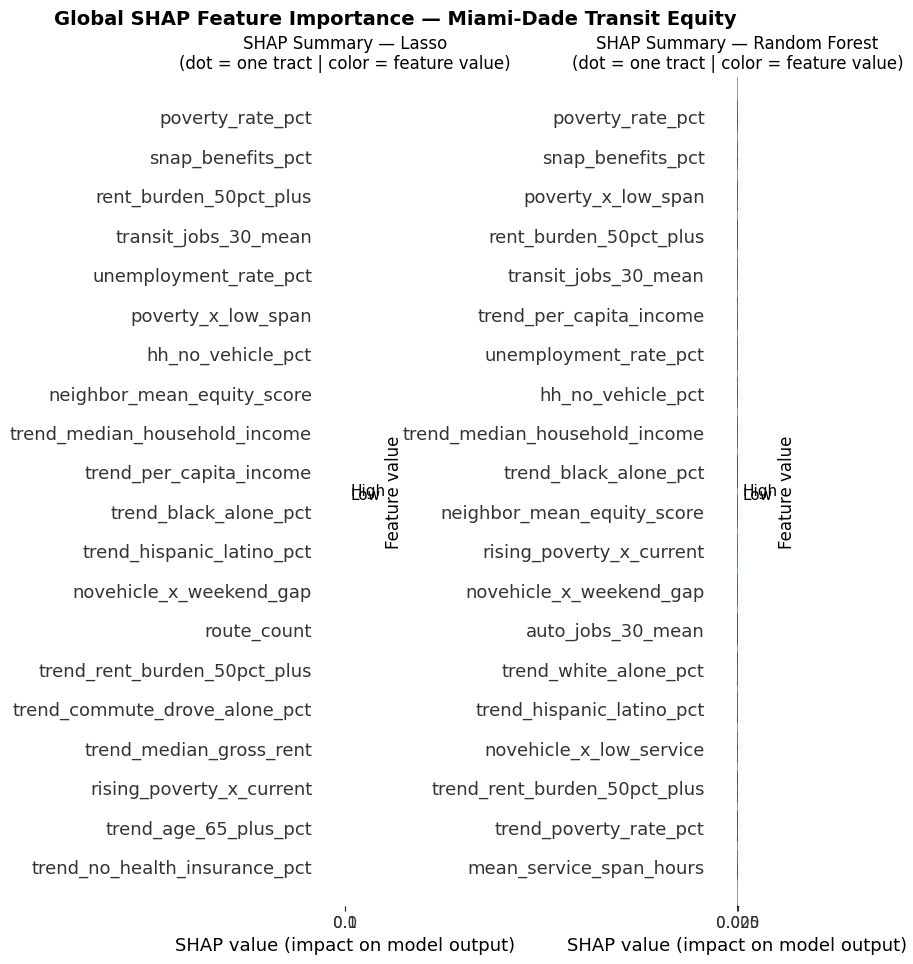

Saved: shap_global_summary.png


In [48]:
# ── SHAP GLOBAL SUMMARY — DOT PLOT ────────────────────────────────────────
# Each dot = one tract
# Color = feature value (red = high, blue = low)
# X position = SHAP value (positive = raises equity score = worsens inequity)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.summary_plot(
    shap_lasso, X_scaled, feature_names=ALL_FEATURES,
    max_display=20, show=False, plot_type='dot'
)
axes[0].set_title('SHAP Summary — Lasso\n(dot = one tract | color = feature value)', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(
    shap_rf, X_imputed, feature_names=ALL_FEATURES,
    max_display=20, show=False, plot_type='dot'
)
axes[1].set_title('SHAP Summary — Random Forest\n(dot = one tract | color = feature value)', fontsize=12)

plt.suptitle('Global SHAP Feature Importance — Miami-Dade Transit Equity',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_global_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_global_summary.png')

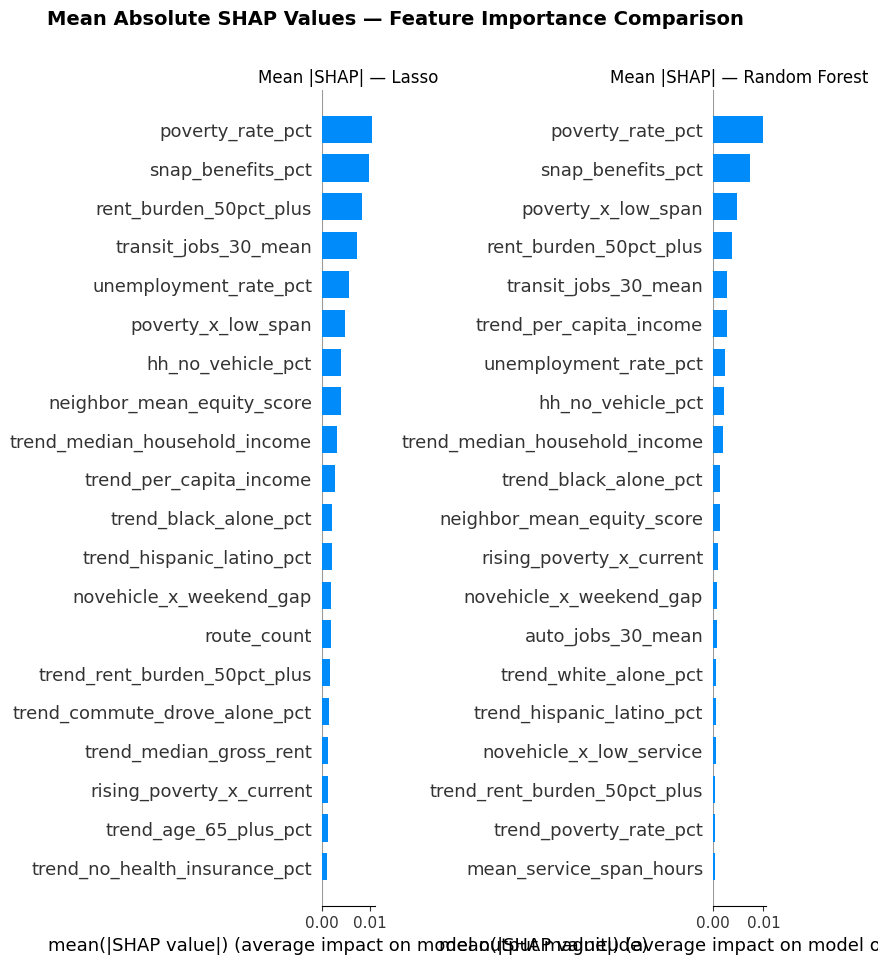

Saved: shap_global_bar.png


In [49]:
# ── SHAP GLOBAL BAR — MEAN ABSOLUTE SHAP ──────────────────────────────────
# This directly answers: which features drive predictions most, on average
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

plt.sca(axes[0])
shap.summary_plot(
    shap_lasso, X_scaled, feature_names=ALL_FEATURES,
    max_display=20, show=False, plot_type='bar'
)
axes[0].set_title('Mean |SHAP| — Lasso', fontsize=12)

plt.sca(axes[1])
shap.summary_plot(
    shap_rf, X_imputed, feature_names=ALL_FEATURES,
    max_display=20, show=False, plot_type='bar'
)
axes[1].set_title('Mean |SHAP| — Random Forest', fontsize=12)

plt.suptitle('Mean Absolute SHAP Values — Feature Importance Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_global_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_global_bar.png')

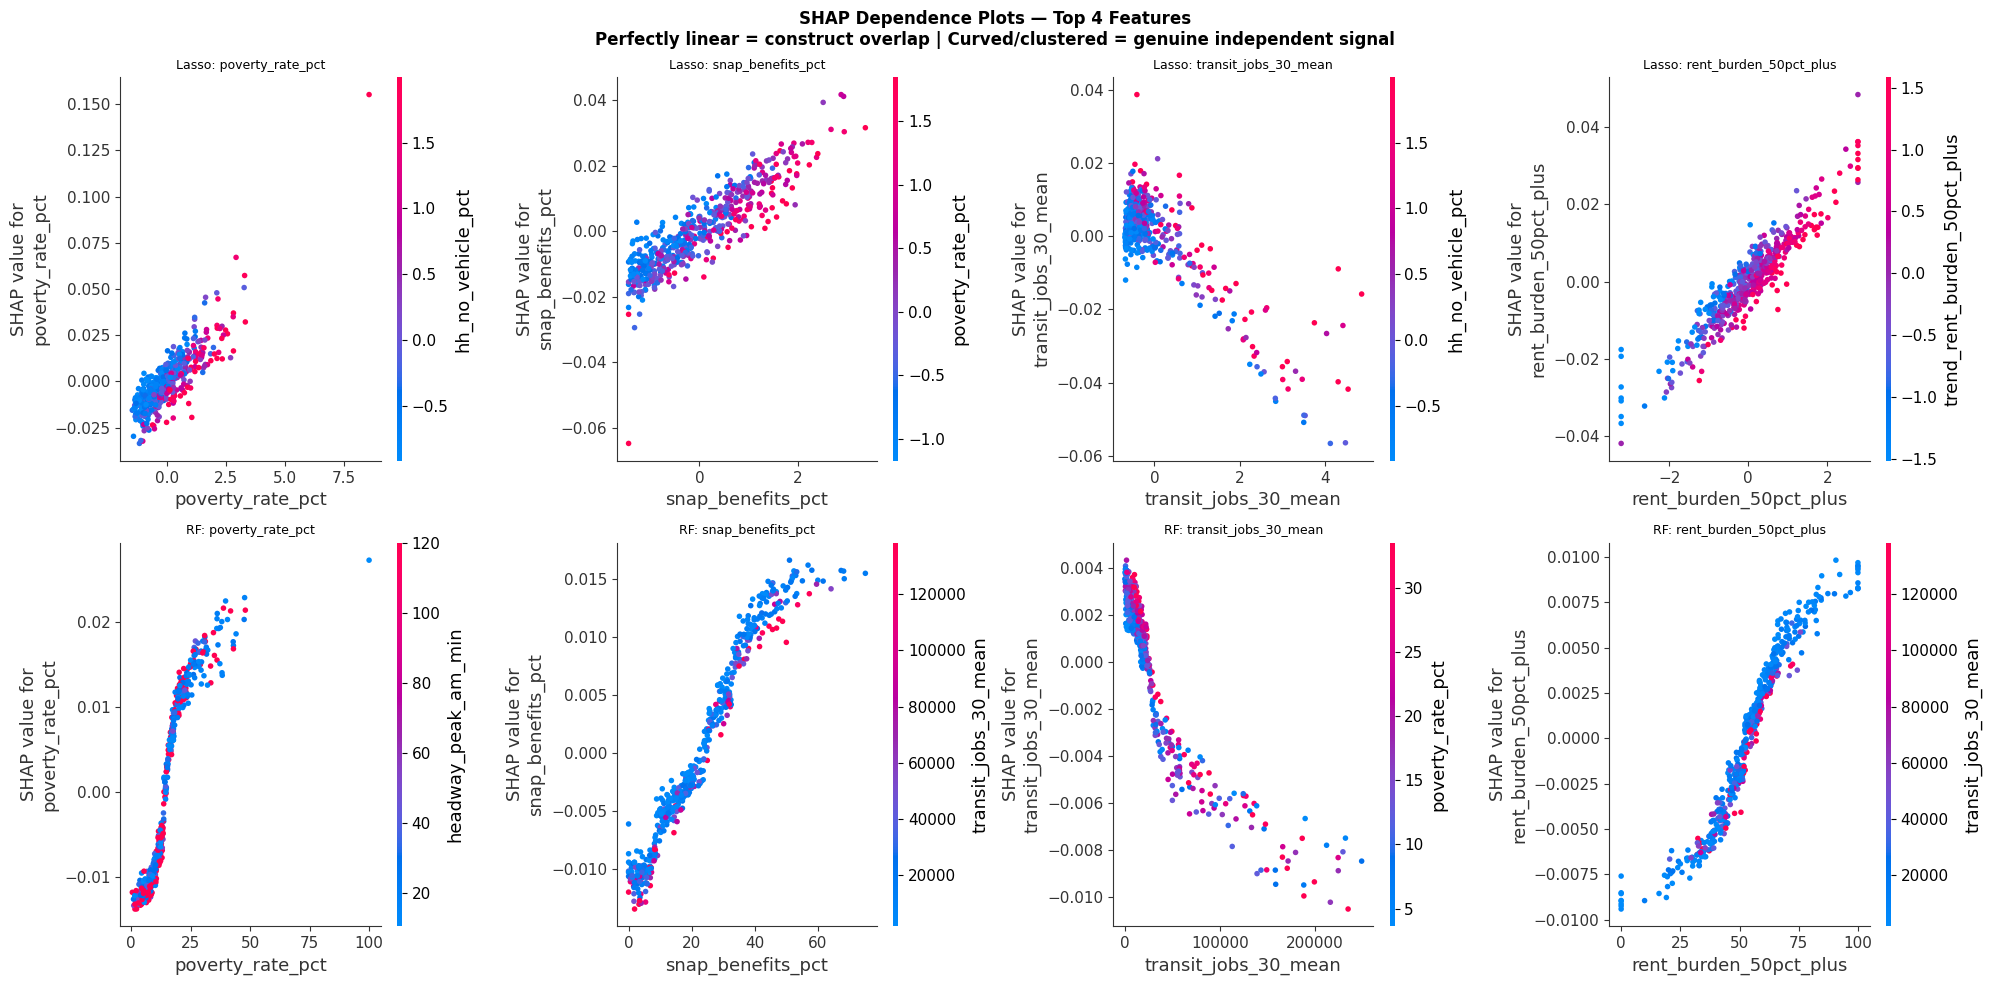

Saved: shap_dependence.png


In [50]:
# ── SHAP DEPENDENCE PLOTS ─────────────────────────────────────────────────
# Shows how SHAP value changes as each feature increases
# KEY DIAGNOSTIC: if poverty_rate_pct is pure construct overlap, its
# relationship should be perfectly linear. Any curve = independent signal.
top_features = [
    'poverty_rate_pct', 'snap_benefits_pct',
    'transit_jobs_30_mean', 'rent_burden_50pct_plus'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, feat in enumerate(top_features):
    shap.dependence_plot(
        feat, shap_lasso, X_scaled,
        feature_names=ALL_FEATURES, ax=axes[0][i], show=False
    )
    axes[0][i].set_title(f'Lasso: {feat}', fontsize=9)

    shap.dependence_plot(
        feat, shap_rf, X_imputed,
        feature_names=ALL_FEATURES, ax=axes[1][i], show=False
    )
    axes[1][i].set_title(f'RF: {feat}', fontsize=9)

plt.suptitle(
    'SHAP Dependence Plots — Top 4 Features\n'
    'Perfectly linear = construct overlap | Curved/clustered = genuine independent signal',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_dependence.png')

  12086003706 — Low | score: 0.0144
  12086012403 — High | score: 0.1298
  12086000312 — Critical | score: 0.1935
  12086007901 — Moderate | score: 0.0954
  12086004701 — High | score: 0.1306


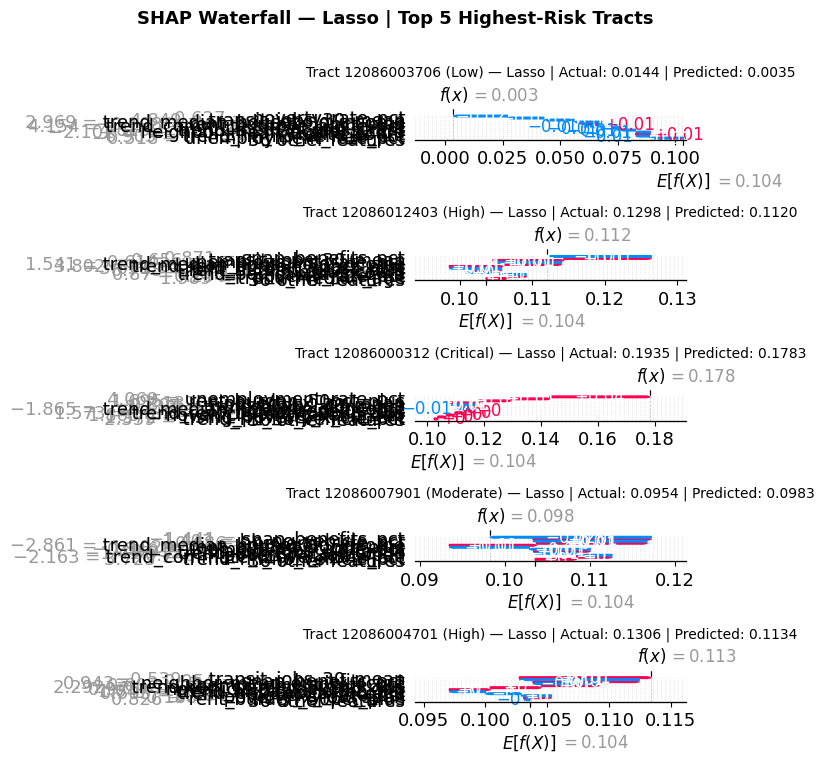

Saved: shap_waterfall_lasso.png


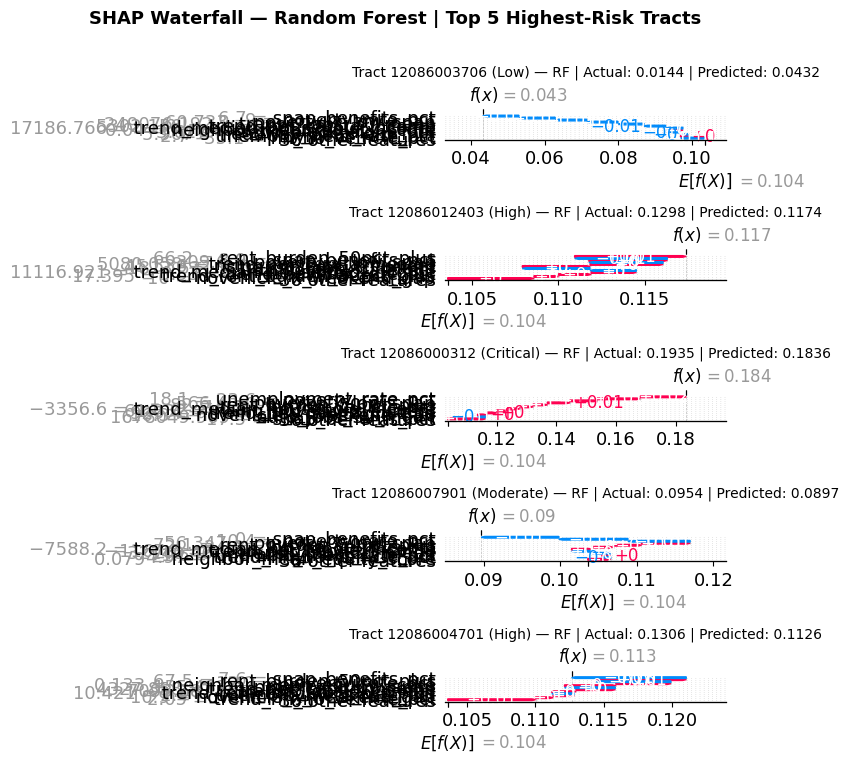

Saved: shap_waterfall_rf.png


In [51]:
# ── SHAP WATERFALL — TOP 5 RISK TRACTS ────────────────────────────────────
# Waterfall shows: base value + each feature's push = final prediction
# Red bars = feature raises equity score (worsens inequity)
# Blue bars = feature lowers equity score (improves equity)

TOP_RISK_GEOIDS = [
    '12086003706',  # Rank 1 — Low tier, extreme trend risk
    '12086012403',  # Rank 2 — High tier
    '12086000312',  # Rank 3 — Critical tier
    '12086007901',  # Rank 4 — Moderate tier
    '12086004701',  # Rank 5 — High tier
]

tract_indices = {}
for geoid in TOP_RISK_GEOIDS:
    matches = np.where(df_model['tract_geoid'].values == geoid)[0]
    if len(matches) > 0:
        tract_indices[geoid] = matches[0]
        print(f'  {geoid} — {df_model["equity_tier"].iloc[matches[0]]} | score: {y.iloc[matches[0]]:.4f}')

# --- Lasso waterfall ---
fig, axes = plt.subplots(len(tract_indices), 1, figsize=(14, 5 * len(tract_indices)))
for ax, (geoid, idx) in zip(axes, tract_indices.items()):
    shap_exp = shap.Explanation(
        values=shap_lasso[idx],
        base_values=lasso_explainer.expected_value,
        data=X_scaled.iloc[idx].values,
        feature_names=ALL_FEATURES
    )
    plt.sca(ax)
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    ax.set_title(
        f'Tract {geoid} ({df_model["equity_tier"].iloc[idx]}) — Lasso | '
        f'Actual: {y.iloc[idx]:.4f} | Predicted: {lasso_final.predict(X_scaled.iloc[[idx]])[0]:.4f}',
        fontsize=10
    )

plt.suptitle('SHAP Waterfall — Lasso | Top 5 Highest-Risk Tracts',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_waterfall_lasso.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall_lasso.png')

# --- RF waterfall ---
fig, axes = plt.subplots(len(tract_indices), 1, figsize=(14, 5 * len(tract_indices)))
for ax, (geoid, idx) in zip(axes, tract_indices.items()):
    shap_exp = shap.Explanation(
        values=shap_rf[idx],
        base_values=rf_explainer.expected_value,
        data=X_imputed.iloc[idx].values,
        feature_names=ALL_FEATURES
    )
    plt.sca(ax)
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    ax.set_title(
        f'Tract {geoid} ({df_model["equity_tier"].iloc[idx]}) — RF | '
        f'Actual: {y.iloc[idx]:.4f} | Predicted: {rf_final.predict(X_imputed.iloc[[idx]])[0]:.4f}',
        fontsize=10
    )

plt.suptitle('SHAP Waterfall — Random Forest | Top 5 Highest-Risk Tracts',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_waterfall_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_waterfall_rf.png')

In [52]:
# ── LIME GLOBAL IMPORTANCE ─────────────────────────────────────────────────
# LIME fits a local linear model around each prediction.
# We run on 150 random tracts and aggregate to get a global picture.

lime_explainer_rf = lime_tabular.LimeTabularExplainer(
    training_data=X_imputed.values,
    feature_names=ALL_FEATURES,
    mode='regression',
    random_state=RANDOM_STATE
)

N_LIME = 150
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_imputed), size=N_LIME, replace=False)

print(f'Running LIME on {N_LIME} tracts...')
lime_weights = {feat: [] for feat in ALL_FEATURES}

for i, idx in enumerate(sample_idx):
    if i % 30 == 0:
        print(f'  {i}/{N_LIME}')
    exp = lime_explainer_rf.explain_instance(
        X_imputed.values[idx],
        rf_final.predict,
        num_features=len(ALL_FEATURES),
        num_samples=500
    )
    for feat_str, weight in exp.as_list():
        base = feat_str.split(' ')[0].split('>')[0].split('<')[0].strip()
        if base in lime_weights:
            lime_weights[base].append(abs(weight))

lime_global = pd.DataFrame([
    {'feature': f, 'lime_importance': np.mean(w) if w else 0}
    for f, w in lime_weights.items()
]).sort_values('lime_importance', ascending=False)

print('\nTop 15 features — LIME global (RF):')
print(lime_global.head(15).to_string(index=False))

Running LIME on 150 tracts...
  0/150
  30/150
  60/150
  90/150
  120/150

Top 15 features — LIME global (RF):
                      feature  lime_importance
             poverty_rate_pct         0.018634
            snap_benefits_pct         0.014183
           poverty_x_low_span         0.009624
       rent_burden_50pct_plus         0.007461
         transit_jobs_30_mean         0.005027
        unemployment_rate_pct         0.004888
      trend_per_capita_income         0.004833
            hh_no_vehicle_pct         0.003772
trend_median_household_income         0.003645
   neighbor_mean_equity_score         0.003545
     rising_poverty_x_current         0.002915
              rail_trip_share         0.002794
        trend_black_alone_pct         0.002684
      novehicle_x_weekend_gap         0.001900
    trend_hispanic_latino_pct         0.001636


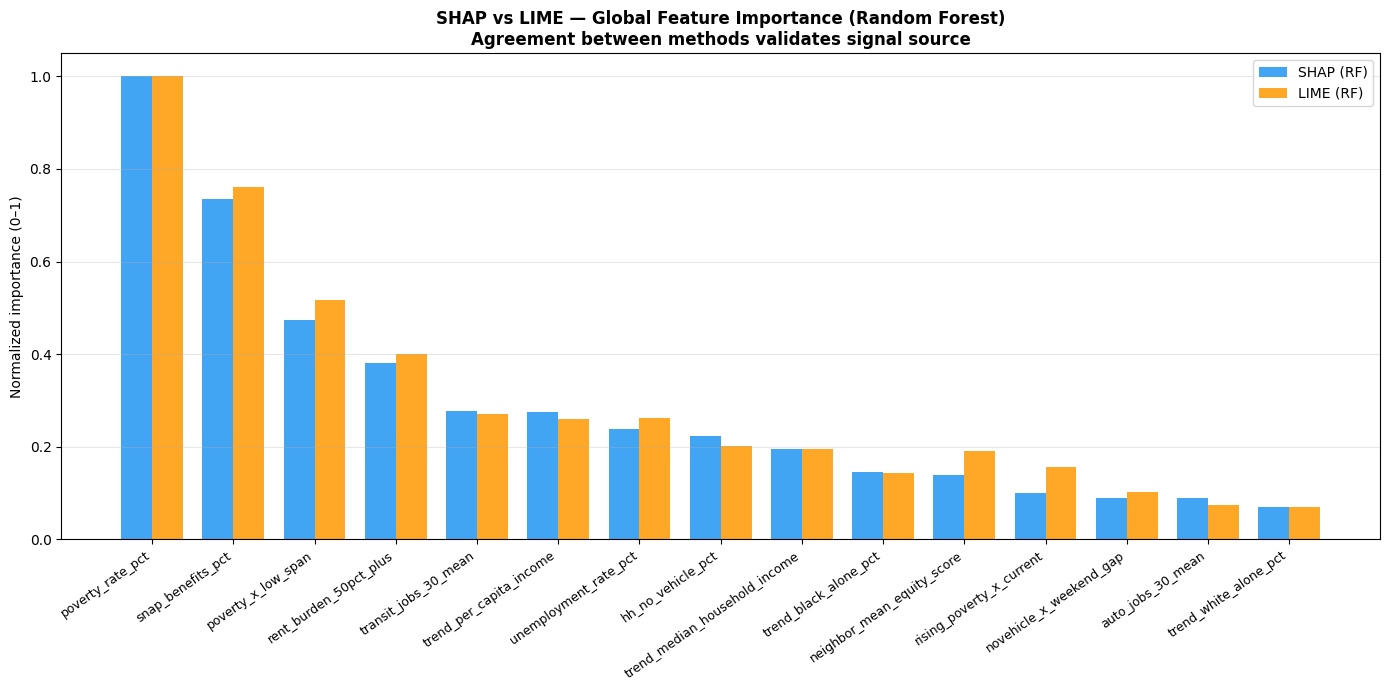

Saved: shap_vs_lime.png


In [53]:
# ── SHAP vs LIME COMPARISON ────────────────────────────────────────────────
# If both methods agree on top features, the signal is robust.
# Disagreement flags features that are locally vs globally important.

top15 = pd.DataFrame({
    'feature': ALL_FEATURES,
    'shap_rf': np.abs(shap_rf).mean(axis=0)
}).sort_values('shap_rf', ascending=False).head(15)['feature'].tolist()

shap_vals = pd.DataFrame({'feature': ALL_FEATURES, 'v': np.abs(shap_rf).mean(axis=0)}).set_index('feature')['v']
lime_vals = lime_global.set_index('feature').reindex(top15)['lime_importance'].fillna(0)
shap_norm = shap_vals[top15] / shap_vals[top15].max()
lime_norm = lime_vals / lime_vals.max() if lime_vals.max() > 0 else lime_vals

x = np.arange(len(top15))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - w/2, shap_norm.values, w, label='SHAP (RF)', color='#2196F3', alpha=0.85)
ax.bar(x + w/2, lime_norm.values, w, label='LIME (RF)', color='#FF9800', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top15, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Normalized importance (0–1)')
ax.set_title(
    'SHAP vs LIME — Global Feature Importance (Random Forest)\n'
    'Agreement between methods validates signal source',
    fontsize=12, fontweight='bold'
)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_vs_lime.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_vs_lime.png')

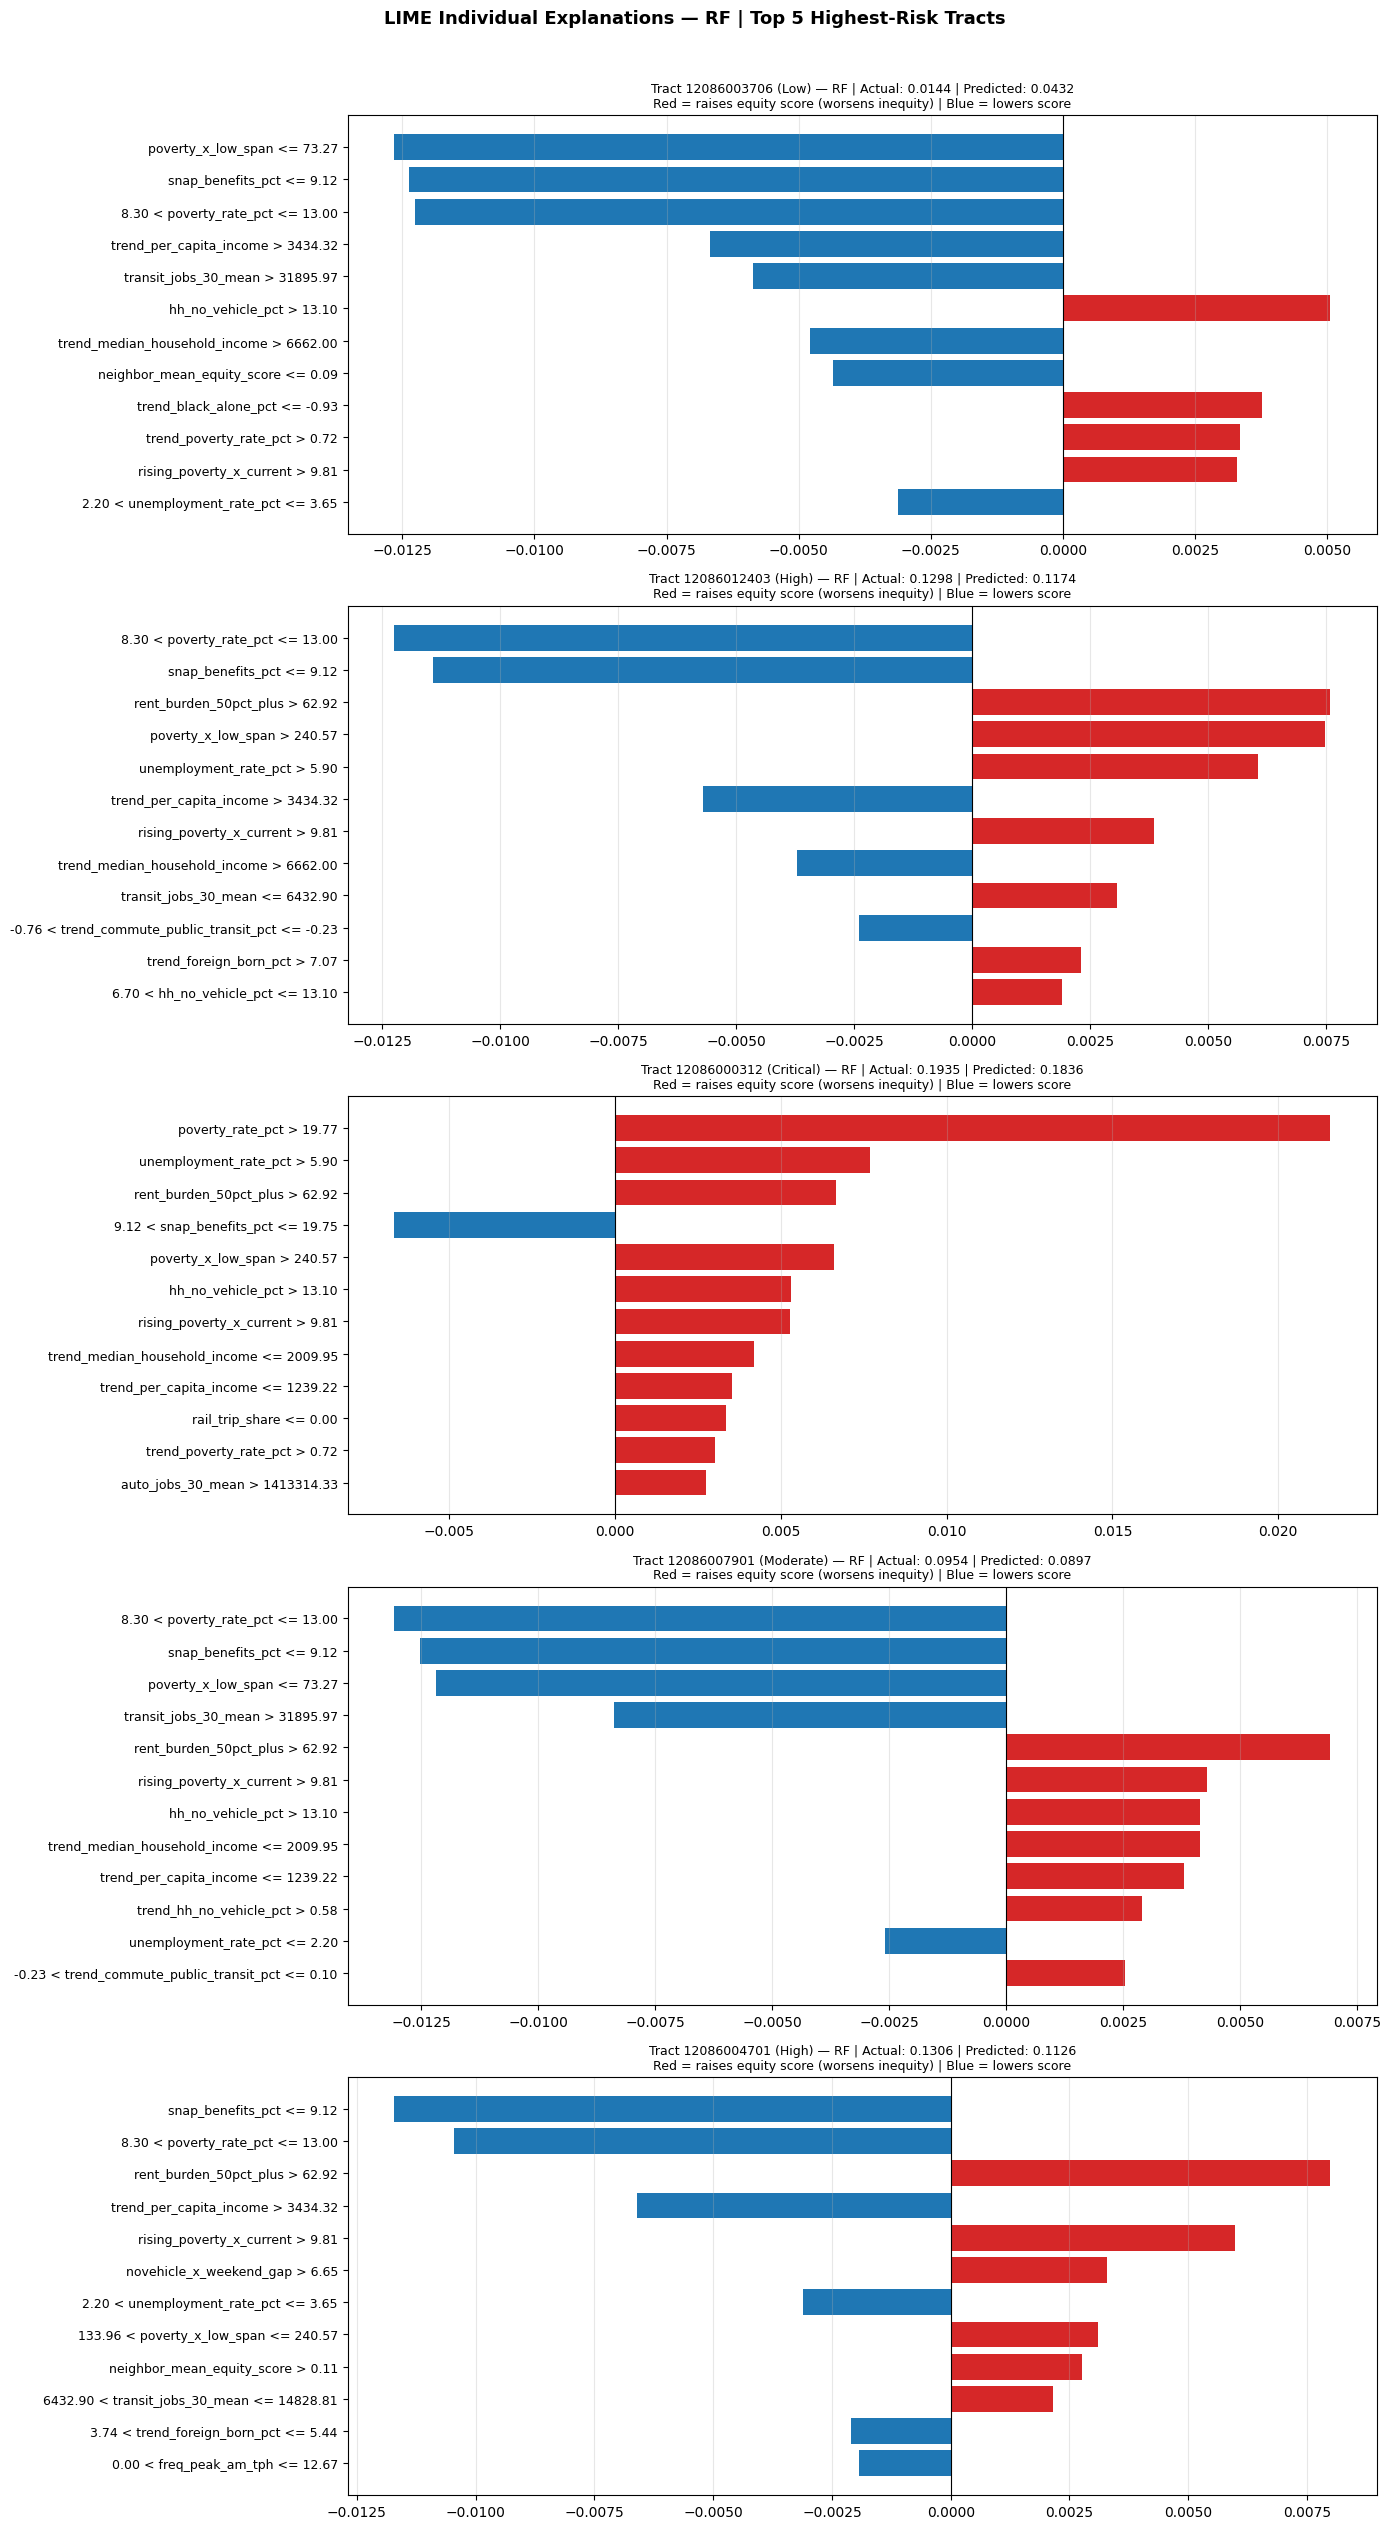

Saved: lime_individual_rf.png


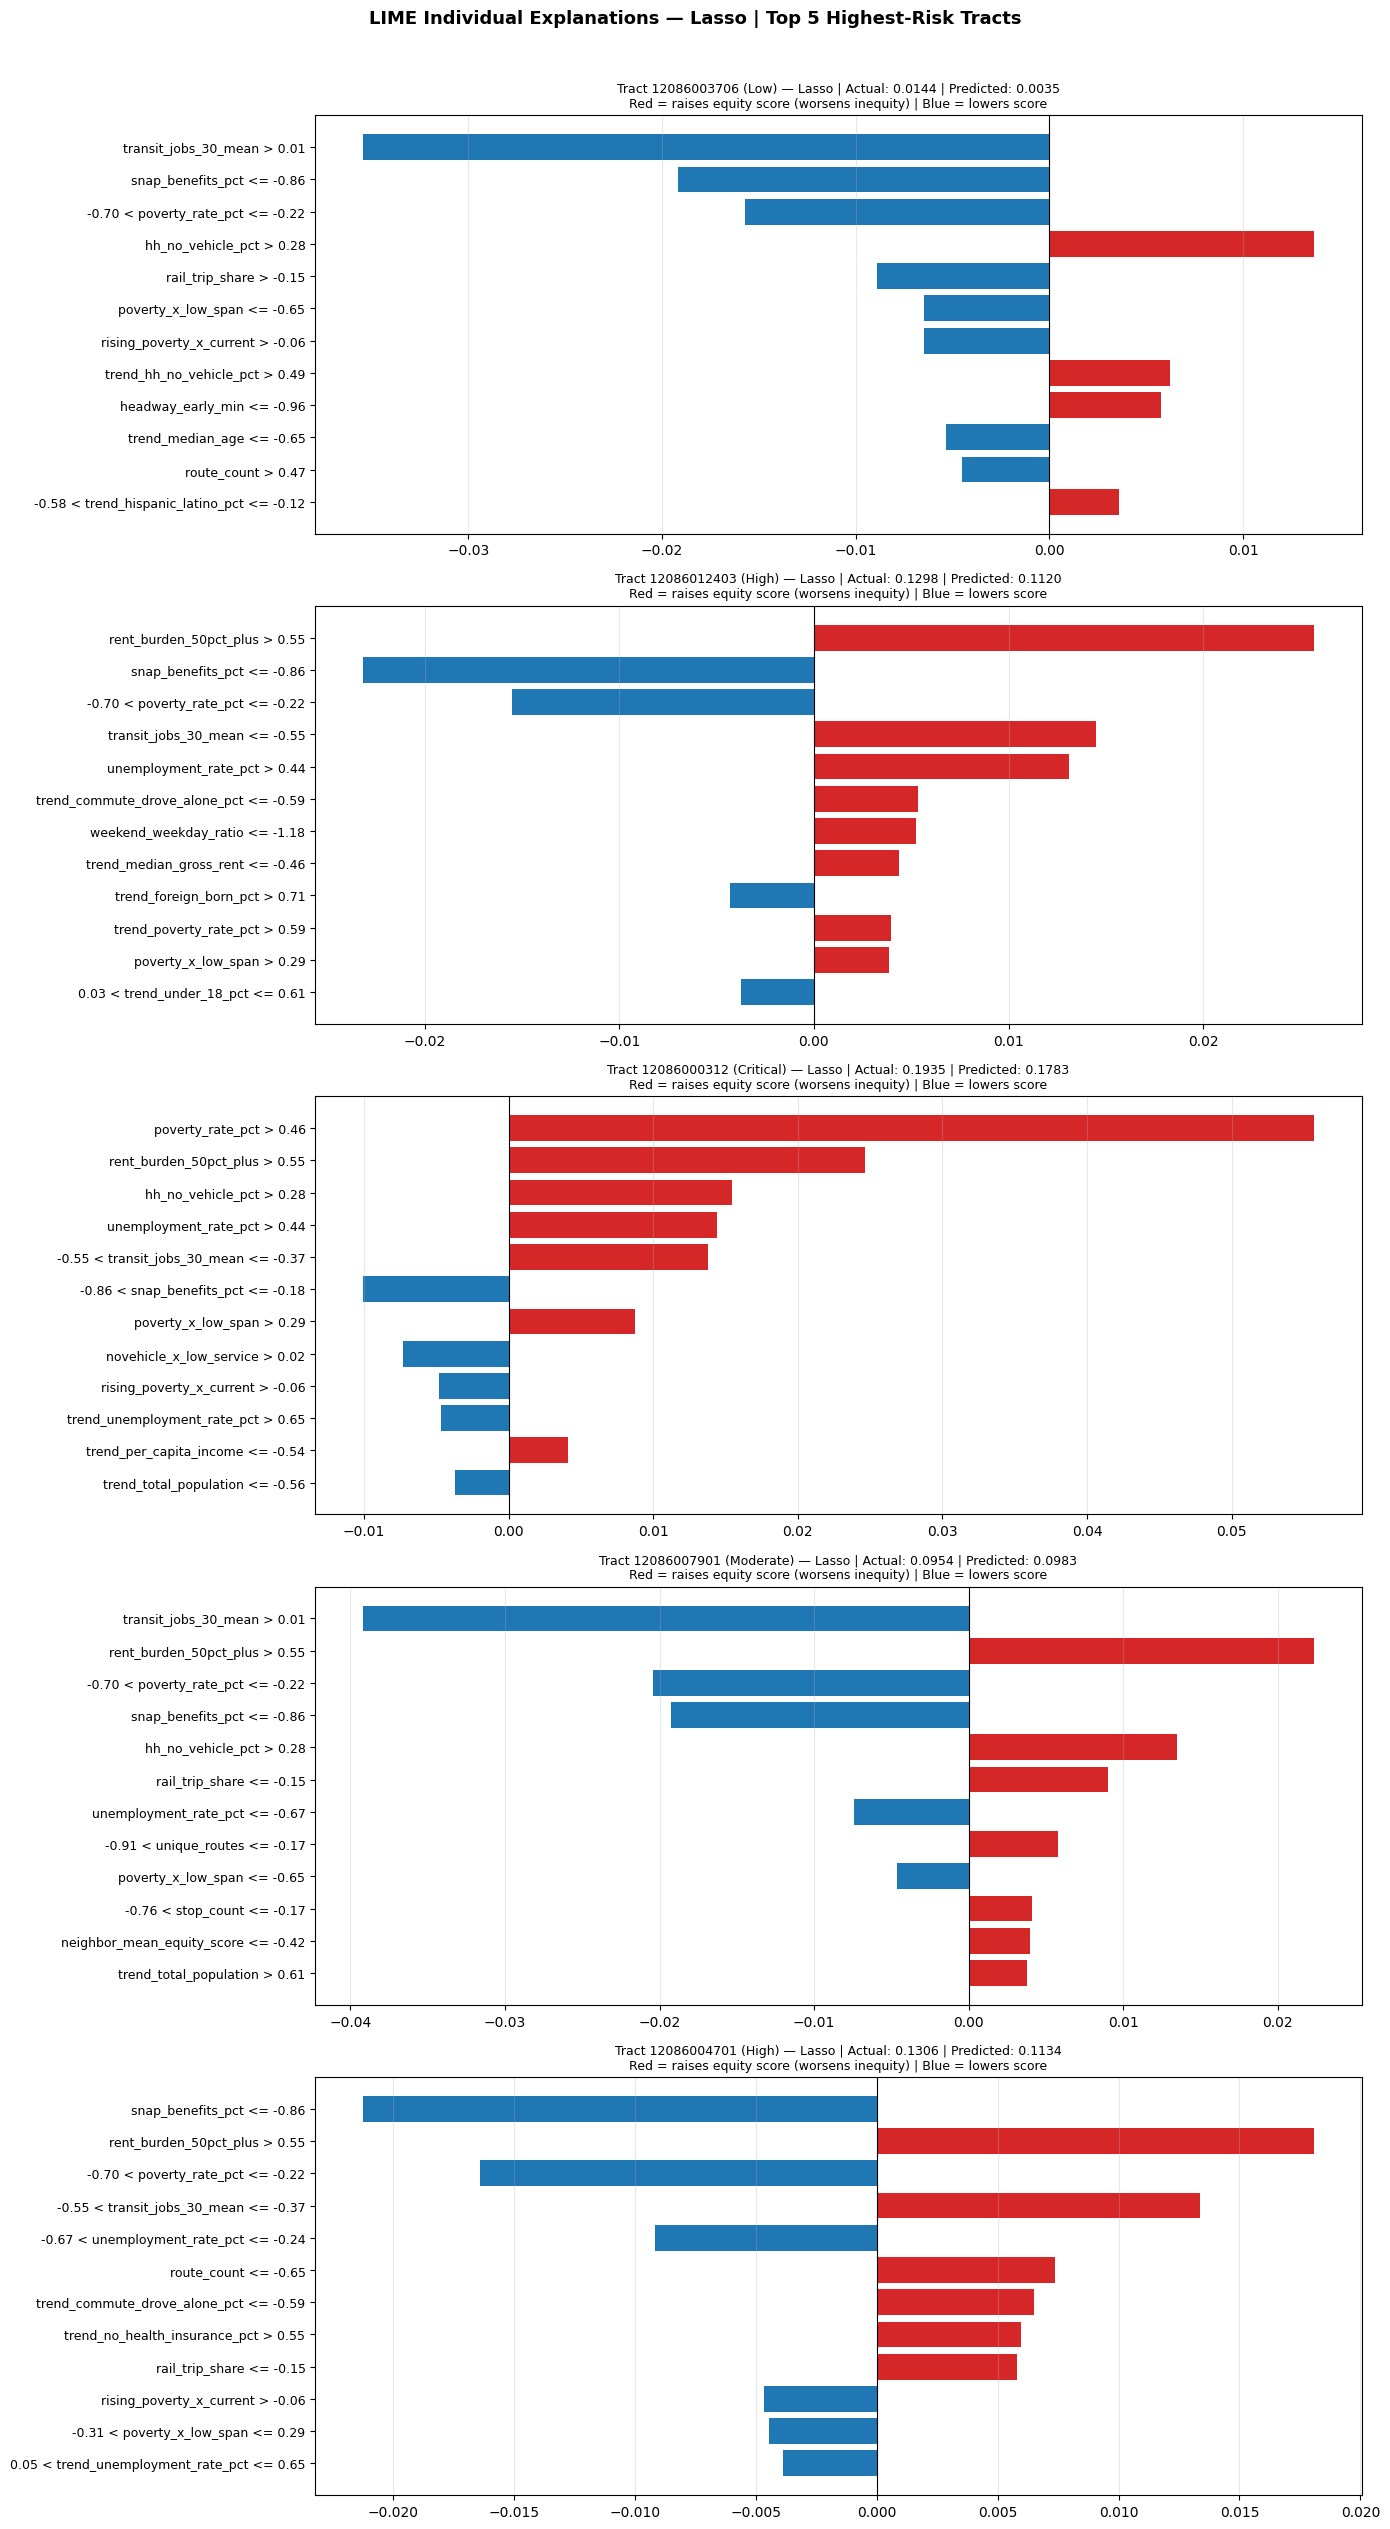

Saved: lime_individual_lasso.png


In [54]:
# ── LIME INDIVIDUAL — TOP 5 RISK TRACTS ───────────────────────────────────
# LIME explanation for each tract: which features drove THAT specific prediction
# Red = raised the predicted score (worsened inequity)
# Blue = lowered the predicted score

lime_explainer_lasso = lime_tabular.LimeTabularExplainer(
    training_data=X_scaled.values,
    feature_names=ALL_FEATURES,
    mode='regression',
    random_state=RANDOM_STATE
)

for model_name, explainer, X_use, model in [
    ('RF',    lime_explainer_rf,    X_imputed, rf_final),
    ('Lasso', lime_explainer_lasso, X_scaled,  lasso_final),
]:
    fig, axes = plt.subplots(len(tract_indices), 1, figsize=(14, 5 * len(tract_indices)))

    for ax, (geoid, idx) in zip(axes, tract_indices.items()):
        exp = explainer.explain_instance(
            X_use.values[idx],
            model.predict,
            num_features=12,
            num_samples=1000
        )
        feat_names = [x[0] for x in exp.as_list()]
        weights    = [x[1] for x in exp.as_list()]
        colors     = ['#d62728' if w > 0 else '#1f77b4' for w in weights]

        ax.barh(range(len(weights)), weights[::-1], color=colors[::-1])
        ax.set_yticks(range(len(weights)))
        ax.set_yticklabels(feat_names[::-1], fontsize=9)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(
            f'Tract {geoid} ({df_model["equity_tier"].iloc[idx]}) — {model_name} | '
            f'Actual: {y.iloc[idx]:.4f} | Predicted: {model.predict(X_use.iloc[[idx]])[0]:.4f}\n'
            f'Red = raises equity score (worsens inequity) | Blue = lowers score',
            fontsize=9
        )
        ax.grid(axis='x', alpha=0.3)

    plt.suptitle(f'LIME Individual Explanations — {model_name} | Top 5 Highest-Risk Tracts',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'lime_individual_{model_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: lime_individual_{model_name.lower()}.png')

In [55]:
# ── EXPORT SHAP + LIME SUMMARY TABLE ──────────────────────────────────────
shap_lasso_mean = pd.DataFrame({
    'feature': ALL_FEATURES,
    'shap_lasso_mean_abs': np.abs(shap_lasso).mean(axis=0)
})
shap_rf_mean = pd.DataFrame({
    'feature': ALL_FEATURES,
    'shap_rf_mean_abs': np.abs(shap_rf).mean(axis=0)
})

explainability_summary = (
    shap_rf_mean
    .merge(shap_lasso_mean, on='feature')
    .merge(lime_global, on='feature', how='left')
    .merge(
        pd.DataFrame({'feature': ALL_FEATURES, 'lasso_coef': lasso_final.coef_}),
        on='feature'
    )
    .sort_values('shap_rf_mean_abs', ascending=False)
    .round(6)
)

print('Top 20 Features — SHAP RF | SHAP Lasso | LIME | Lasso Coef:')
print(explainability_summary.head(20).to_string(index=False))

explainability_summary.to_csv('Sprint2b_Explainability_Summary.csv', index=False)
print('\nExported: Sprint2b_Explainability_Summary.csv')

Top 20 Features — SHAP RF | SHAP Lasso | LIME | Lasso Coef:
                      feature  shap_rf_mean_abs  shap_lasso_mean_abs  lime_importance  lasso_coef
             poverty_rate_pct          0.009994             0.010535         0.018634    0.024541
            snap_benefits_pct          0.007355             0.009815         0.014183    0.013526
           poverty_x_low_span          0.004727             0.004928         0.009624    0.003574
       rent_burden_50pct_plus          0.003812             0.008426         0.007461    0.012453
         transit_jobs_30_mean          0.002770             0.007435         0.005027   -0.017531
      trend_per_capita_income          0.002759             0.002712         0.004833    0.000403
        unemployment_rate_pct          0.002385             0.005738         0.004888    0.005562
            hh_no_vehicle_pct          0.002234             0.004005         0.003772    0.006269
trend_median_household_income          0.001949           